# Proyecto de aula — Fundamentos de Ciencia de Datos

## Análisis exploratorio y caracterización de variables fisicoquímicas asociadas a la calidad del vino

---

**Autores**

Jose Camilo Loaiza Hoyos — camilo.loaiza1@udea.edu.co  
Sarai Restrepo Rodríguez — sarai.restrepo@udea.edu.co  

**Curso:** Fundamentos de Ciencia de Datos  
**Docente:** María Bernarda Salazar Sánchez  
**Programa:** Ingeniería de Sistemas · Universidad de Antioquia  
**Semestre:** 2026-1  
**Conjunto de datos:** *Wine Quality* — UCI Machine Learning Repository (Cortez et al., 2009)

---

## Resumen

Este trabajo analiza el conjunto de datos *Wine Quality* del UCI Machine Learning Repository (Cortez et al., 2009), compuesto por 6 497 muestras de vinos *Vinho Verde* portugueses (1 599 tintos y 4 898 blancos) con 11 variables fisicoquímicas continuas y una evaluación sensorial de calidad ordinal. El objetivo es caracterizar dichas variables e identificar cuáles presentan mayor asociación con la calidad sensorial, mediante un proceso analítico completo de ciencia de datos. Se aplicaron técnicas de análisis exploratorio univariado, bivariado y multivariado —incluyendo Análisis de Componentes Principales (PCA)—, métodos de detección de valores atípicos (rango intercuartílico, puntaje Z, Isolation Forest y LOF) y estrategias de preprocesamiento que comprenden eliminación de duplicados, transformación Yeo–Johnson para variables asimétricas y escalamiento con StandardScaler. Los resultados muestran que `alcohol` es la variable con mayor correlación monótona con la calidad (ρ de Spearman ≈ 0,45), seguida por `density` (ρ ≈ −0,32) y `chlorides` (ρ ≈ −0,30). El PCA evidencia que el primer componente separa nítidamente los vinos tintos de los blancos, mientras que el gradiente de calidad en el espacio reducido es difuso, lo que anticipa la necesidad de modelos no lineales para su predicción. Se concluye que las variables fisicoquímicas permiten caracterizar parcialmente la calidad, pero el desbalance ordinal de clases y la naturaleza subjetiva de la variable objetivo representan retos para el modelado supervisado posterior.

**Palabras clave:** calidad del vino; análisis exploratorio de datos; detección de valores atípicos; transformación Yeo–Johnson; análisis de componentes principales

## Tabla de contenido

0. **Resumen y palabras clave**
1. **Unidad 1 — Comprensión y contextualización del problema**
   1. Introducción y pregunta de investigación
   2. Objetivos
   3. Descripción del conjunto de datos
   4. Configuración del entorno
   5. Carga de datos
   6. Inspección inicial
   7. Hallazgos preliminares y próximos pasos
2. **Unidad 2 — Análisis exploratorio de datos**
   1. Análisis univariado (estadísticas descriptivas, histogramas, boxplots)
   2. Análisis bivariado (correlaciones Pearson/Spearman, comparación por tipo, χ²)
   3. Análisis multivariado (PCA: varianza explicada, biplot, proyecciones)
   4. Síntesis de hallazgos del EDA
3. **Unidad 3 — Detección y tratamiento de datos atípicos**
   1. Métodos gráficos y estadísticos univariados (IQR y Z-score)
   2. Métodos de aprendizaje automático multivariados (Isolation Forest y LOF)
   3. Síntesis y plan de tratamiento
4. **Unidad 4 — Imputación, escalamiento y transformación**
   1. Limpieza inicial (faltantes y duplicados)
   2. Imputación KNN (escenario MCAR simulado)
   3. Transformación Yeo–Johnson
   4. Comparación y selección de escaladores
   5. Exportación del conjunto procesado
5. **Conclusiones generales del proyecto**
   1. Hallazgos principales
   2. Limitaciones
   3. Trabajo futuro
   4. Consideraciones éticas y reproducibilidad
6. **Referencias**

## 1. Introducción y pregunta de investigación

La industria vitivinícola es uno de los sectores agroalimentarios de mayor relevancia económica a nivel mundial, y la calidad del vino constituye uno de sus principales criterios de valor comercial y sensorial (Cortez et al., 2009). Tradicionalmente, la evaluación de la calidad se ha realizado mediante catas sensoriales llevadas a cabo por paneles de expertos, un proceso que, si bien es efectivo, introduce cierto grado de subjetividad y variabilidad entre catadores (Barnett & Lewis, 1994). Frente a esta limitación, el análisis de variables fisicoquímicas medibles en laboratorio ofrece una alternativa reproducible y cuantificable para estimar y comprender la calidad del vino desde una perspectiva basada en datos (Cortez et al., 2009; UCI Machine Learning Repository, 2009).

El presente trabajo aborda este problema a partir del conjunto de datos *Wine Quality* del UCI Machine Learning Repository (Cortez et al., 2009), que reúne mediciones de vinos *Vinho Verde* portugueses (variantes tinto y blanco) junto con una calificación sensorial entera entre 0 y 10 asignada por un panel de catadores.

> **Pregunta de investigación.** *¿Qué variables fisicoquímicas permiten predecir de mejor manera la calidad del vino?*

Este proyecto no construye un modelo predictivo: su alcance es **exploratorio y descriptivo**. Buscamos identificar qué variables muestran asociación más clara con la calidad, qué patrones diferencian el vino tinto del blanco, y qué tratamientos de calidad de datos (atípicos, escalamiento, transformación) resultan necesarios antes de cualquier modelado posterior.

### 1.1 Objetivos

**Objetivo general.** Caracterizar las variables fisicoquímicas del conjunto *Wine Quality* y determinar cuáles presentan mayor asociación con la calidad sensorial del vino, mediante un proceso analítico completo de ciencia de datos.

**Objetivos específicos.**
1. Describir la estructura, tipos y calidad inicial del conjunto de datos.
2. Aplicar técnicas de análisis exploratorio univariado, bivariado y multivariado para identificar patrones y relaciones.
3. Detectar y documentar valores atípicos mediante métodos gráficos, estadísticos y de aprendizaje automático.
4. Aplicar estrategias de imputación, escalamiento y transformación que preparen los datos para análisis posteriores.


### 1.2 Descripción del conjunto de datos

El repositorio UCI provee dos archivos separados, uno por cada tipo de vino, con la misma estructura de variables. Las dimensiones reportadas por la fuente original son:

| Subconjunto | Observaciones | Variables |
|---|---:|---:|
| Vino tinto (`winequality-red.csv`) | 1599 | 12 |
| Vino blanco (`winequality-white.csv`) | 4898 | 12 |

Las once primeras variables son mediciones fisicoquímicas continuas; la duodécima, `quality`, es una variable categórica ordinal entera obtenida como mediana de tres evaluaciones sensoriales independientes realizadas por catadores. La siguiente tabla resume cada atributo:

| # | Variable | Tipo | Descripción breve |
|---:|---|---|---|
| 1 | `fixed acidity` | continua | Ácidos no volátiles, principal componente de la acidez del vino. |
| 2 | `volatile acidity` | continua | Ácidos volátiles; valores altos producen sabor a vinagre. |
| 3 | `citric acid` | continua | Aporta frescura y aroma cítrico en pequeñas cantidades. |
| 4 | `residual sugar` | continua | Azúcar remanente tras la fermentación. |
| 5 | `chlorides` | continua | Contenido de sal. |
| 6 | `free sulfur dioxide` | continua | SO₂ libre; previene crecimiento microbiano y oxidación. |
| 7 | `total sulfur dioxide` | continua | SO₂ libre + ligado. |
| 8 | `density` | continua | Densidad del líquido, depende de alcohol y azúcar. |
| 9 | `pH` | continua | Acidez en escala logarítmica (0–14). |
| 10 | `sulphates` | continua | Aditivo antimicrobiano y antioxidante. |
| 11 | `alcohol` | continua | Porcentaje de alcohol. |
| 12 | `quality` | ordinal (0–10) | Calificación sensorial mediana del panel de catadores. |

**Justificación metodológica.** El conjunto es ideal para un proyecto de fundamentos: variables completamente numéricas, escala manejable, dominio interpretable y una variable objetivo (`quality`) que permite estudiar relaciones bivariadas y multivariadas con sentido aplicado. La existencia de dos subconjuntos (tinto y blanco) habilita además un análisis comparativo enriquecido.

### 1.3 Configuración del entorno



In [94]:
import os

if "google.colab" in str(get_ipython()):
    !git clone https://github.com/caamilo03/wine-quality.git
    os.chdir("wine-quality/proyecto_aula")

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# --- Reproducibilidad 
SEED = 42
np.random.seed(SEED)

# --- Configuración estética de las gráficas 
sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- pandas 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# --- Rutas del proyecto 
RAIZ = Path.cwd().parent if Path.cwd().name == "proyecto_aula" else Path.cwd()
RUTA_DATOS = RAIZ / "datos"
RUTA_PROCESADOS = RUTA_DATOS / "procesados"
RUTA_FIGURAS = RAIZ / "articulo" / "figuras"

print(f"Raíz del proyecto:  {RAIZ}")
print(f"Datos crudos:       {RUTA_DATOS}")
print(f"Datos procesados:   {RUTA_PROCESADOS}")
print(f"Figuras (artículo): {RUTA_FIGURAS}")

Raíz del proyecto:  c:\Users\Camilo\Documents\F. Ciencia de datos\wine-quality
Datos crudos:       c:\Users\Camilo\Documents\F. Ciencia de datos\wine-quality\datos
Datos procesados:   c:\Users\Camilo\Documents\F. Ciencia de datos\wine-quality\datos\procesados
Figuras (artículo): c:\Users\Camilo\Documents\F. Ciencia de datos\wine-quality\articulo\figuras


### 1.4 Carga de datos

Los archivos del UCI utilizan punto y coma (`;`) como separador. Cargamos cada subconjunto por separado, añadimos una variable categórica `tipo` que identifica el origen (tinto o blanco) y los unimos en un único `DataFrame` para facilitar el análisis comparativo.

In [96]:
tinto = pd.read_csv(RUTA_DATOS / "winequality-red.csv", sep=";")
blanco = pd.read_csv(RUTA_DATOS / "winequality-white.csv", sep=";")

# Etiqueta de origen para análisis comparativo
tinto["tipo"] = "tinto"
blanco["tipo"] = "blanco"

# Conjunto unificado
vinos = pd.concat([tinto, blanco], ignore_index=True)
vinos["tipo"] = vinos["tipo"].astype("category")

print(f"Tinto:    {tinto.shape[0]:>5} filas × {tinto.shape[1]} columnas")
print(f"Blanco:   {blanco.shape[0]:>5} filas × {blanco.shape[1]} columnas")
print(f"Unificado:{vinos.shape[0]:>5} filas × {vinos.shape[1]} columnas")

Tinto:     1599 filas × 13 columnas
Blanco:    4898 filas × 13 columnas
Unificado: 6497 filas × 13 columnas


In [97]:
vinos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,tinto
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5,tinto
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5,tinto
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6,tinto
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,tinto


### 1.5 Inspección inicial

Antes de empezar el análisis exploratorio formal, verificamos cuatro aspectos básicos de calidad de datos:

1. **Tipos y memoria.** 
2. **Resumen estadístico.**
3. **Valores faltantes y duplicados.** 
4. **Distribución por tipo y por calidad.**  

#### 1.5.1 Tipos de datos

In [98]:
vinos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         6497 non-null   float64 
 1   volatile acidity      6497 non-null   float64 
 2   citric acid           6497 non-null   float64 
 3   residual sugar        6497 non-null   float64 
 4   chlorides             6497 non-null   float64 
 5   free sulfur dioxide   6497 non-null   float64 
 6   total sulfur dioxide  6497 non-null   float64 
 7   density               6497 non-null   float64 
 8   pH                    6497 non-null   float64 
 9   sulphates             6497 non-null   float64 
 10  alcohol               6497 non-null   float64 
 11  quality               6497 non-null   int64   
 12  tipo                  6497 non-null   category
dtypes: category(1), float64(11), int64(1)
memory usage: 615.7 KB


#### 1.5.2 Resumen estadístico

In [99]:
vinos.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,"6,497.0000",7.2153,1.2964,3.8000,6.4000,7.0000,7.7000,15.9000
volatile acidity,"6,497.0000",0.3397,0.1646,0.0800,0.2300,0.2900,0.4000,1.5800
citric acid,"6,497.0000",0.3186,0.1453,0.0000,0.2500,0.3100,0.3900,1.6600
residual sugar,"6,497.0000",5.4432,4.7578,0.6000,1.8000,3.0000,8.1000,65.8000
chlorides,"6,497.0000",0.0560,0.0350,0.0090,0.0380,0.0470,0.0650,0.6110
free sulfur dioxide,"6,497.0000",30.5253,17.7494,1.0000,17.0000,29.0000,41.0000,289.0000
total sulfur dioxide,"6,497.0000",115.7446,56.5219,6.0000,77.0000,118.0000,156.0000,440.0000
density,"6,497.0000",0.9947,0.0030,0.9871,0.9923,0.9949,0.9970,1.0390
pH,"6,497.0000",3.2185,0.1608,2.7200,3.1100,3.2100,3.3200,4.0100
sulphates,"6,497.0000",0.5313,0.1488,0.2200,0.4300,0.5100,0.6000,2.0000


#### 1.5.3 Valores faltantes y duplicados

In [100]:
faltantes = vinos.isna().sum()
faltantes = faltantes[faltantes > 0]

print("Valores faltantes por columna:")
if faltantes.empty:
    print("  ninguno.")
else:
    print(faltantes.to_string())

n_dup = vinos.duplicated().sum()
print(f"\nFilas duplicadas exactas: {n_dup} "
      f"({100 * n_dup / len(vinos):.2f} % del total)")

Valores faltantes por columna:
  ninguno.

Filas duplicadas exactas: 1177 (18.12 % del total)


#### 1.5.4 Distribución por tipo y por calidad

In [101]:
conteo_tipo = vinos["tipo"].value_counts().rename("n")
conteo_tipo_pct = (conteo_tipo / conteo_tipo.sum() * 100).round(2).rename("%")
pd.concat([conteo_tipo, conteo_tipo_pct], axis=1)

,n,%
tipo,,
blanco,4898,75.3900
tinto,1599,24.6100


In [102]:
tabla_quality = (
    vinos.groupby(["tipo", "quality"], observed=True)
         .size()
         .unstack(fill_value=0)
         .sort_index(axis=1)
)
tabla_quality["total"] = tabla_quality.sum(axis=1)
tabla_quality

quality,3,4,5,6,7,8,9,total
tipo,,,,,,,,
blanco,20,163,1457,2198,880,175,5,4898
tinto,10,53,681,638,199,18,0,1599


### 1.6 Hallazgos preliminares y próximos pasos

A partir de la inspección inicial podemos consignar las siguientes observaciones, que servirán como punto de partida:

- **Estructura.** El conjunto unificado contiene **6 497 observaciones** y **13 columnas** (11 variables fisicoquímicas continuas, la variable objetivo `quality` y la variable categórica `tipo`).
- **Calidad inicial de los datos.** No se reportan valores faltantes en la fuente original; sin embargo, hay un número no despreciable de filas duplicadas exactas, cuyo tratamiento se discutirá más adelante.
- **Desbalance entre subconjuntos.** El vino blanco representa aproximadamente tres cuartas partes del total, lo cual debe considerarse al hacer comparaciones por tipo.
- **Variable objetivo concentrada en clases medias.** La mayoría de los vinos reciben puntuaciones entre 5 y 7; las clases extremas (3, 4, 8, 9) son muy escasas. Este puede ser un caso de desbalance de clases ordinales que puede ser relevante en cualquier modelado supervisado posterior.
- **Escalas** Las variables se mueven en órdenes de magnitud muy distintos (densidad $\approx 1$ vs. dióxido de azufre total con valores $> 200$). Esto anticipa la necesidad de escalamiento antes de cualquier técnica sensible a la magnitud (PCA, k-means, modelos basados en distancia).

---

## 2. Análisis Exploratorio de Datos

Las técnicas empleadas siguen las orientaciones de las sesiones teóricas del curso (Unidad 2):

| Nivel | Técnicas |
|---|---|
| **Univariado** | Tendencia central, dispersión, asimetría, curtosis, percentiles, histogramas, boxplots. |
| **Bivariado** | Coeficientes de correlación de Pearson y Spearman; tablas cruzadas; prueba $\chi^2$ de independencia; comparación de medias. |
| **Multivariado** | Análisis de Componentes Principales (PCA) con visualización 2D y biplot. |

Las figuras relevantes para el artículo se exportan automáticamente a `articulo/figuras/`.

In [ ]:
# Función auxiliar para exportar figuras al artículo de forma consistente.
def guardar_figura(nombre, fig=None):
    # Guarda la figura activa (o la que se indique) en articulo/figuras/.
    figura = fig if fig is not None else plt.gcf()
    RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)  # crea el directorio si no existe
    ruta = RUTA_FIGURAS / f"{nombre}.png"
    figura.savefig(ruta)
    return ruta

# Lista de variables fisicoquímicas (excluye `quality` y `tipo`)
VARS_FQ = [c for c in vinos.columns if c not in ("quality", "tipo")]
print(f"Variables fisicoquímicas ({len(VARS_FQ)}): {VARS_FQ}")

Variables fisicoquímicas (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### 2.1 Análisis univariado

El análisis univariado caracteriza cada variable de forma independiente. Para variables continuas se reportan medidas de tendencia central, dispersión y forma (asimetría y curtosis); para la variable ordinal `quality` y la categórica `tipo` se reportan distribuciones de frecuencia.

#### 2.1.1 Estadísticas descriptivas

Tabla resumen con medidas de tendencia central (media, mediana), dispersión (desviación estándar, coeficiente de variación) y forma (**asimetría** y **curtosis**) para cada variable continua. Variables con $|s| > 1$ y curtosis $> 3$ son candidatas a transformación en la Unidad 4.

In [ ]:
from scipy.stats import skew, kurtosis

def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)

descriptivas = vinos[VARS_FQ + ["quality"]].agg(
    ["mean", "std", "min", q1, "median", q3, "max"]
).T
descriptivas.columns = ["media", "desv. est.", "mín.", "Q1", "mediana", "Q3", "máx."]
descriptivas["asimetría"] = vinos[descriptivas.index].apply(lambda x: skew(x, bias=False))
descriptivas["curtosis"] = vinos[descriptivas.index].apply(lambda x: kurtosis(x, bias=False))
descriptivas["coef. var. (%)"] = (descriptivas["desv. est."] / descriptivas["media"]) * 100
descriptivas

,media,desv. est.,mín.,Q1,mediana,Q3,máx.,asimetría,curtosis,coef. var. (%)
fixed acidity,7.2153,1.2964,3.8000,6.4000,7.0000,7.7000,15.9000,1.7233,5.0612,17.9678
volatile acidity,0.3397,0.1646,0.0800,0.2300,0.2900,0.4000,1.5800,1.4951,2.8254,48.4701
citric acid,0.3186,0.1453,0.0000,0.2500,0.3100,0.3900,1.6600,0.4717,2.3972,45.6066
residual sugar,5.4432,4.7578,0.6000,1.8000,3.0000,8.1000,65.8000,1.4354,4.3593,87.4076
chlorides,0.0560,0.0350,0.0090,0.0380,0.0470,0.0650,0.6110,5.3998,50.8981,62.5222
free sulfur dioxide,30.5253,17.7494,1.0000,17.0000,29.0000,41.0000,289.0000,1.2201,7.9062,58.1465
total sulfur dioxide,115.7446,56.5219,6.0000,77.0000,118.0000,156.0000,440.0000,-0.0012,-0.3717,48.8333
density,0.9947,0.0030,0.9871,0.9923,0.9949,0.9970,1.0390,0.5036,6.6061,0.3015
pH,3.2185,0.1608,2.7200,3.1100,3.2100,3.3200,4.0100,0.3868,0.3677,4.9957
sulphates,0.5313,0.1488,0.2200,0.4300,0.5100,0.6000,2.0000,1.7973,8.6537,28.0096


**Lectura.** Variables con **asimetría |s| > 1** y **curtosis > 3** son candidatas a transformaciones (logarítmica, raíz, Yeo-Johnson). Un coeficiente de variación elevado señala además una dispersión relativa importante respecto a la media.

#### 2.1.2 Distribuciones por variable

Visualizamos la forma de cada distribución con histogramas y curvas de densidad, separando por tipo de vino para evidenciar diferencias estructurales entre ambos subconjuntos.

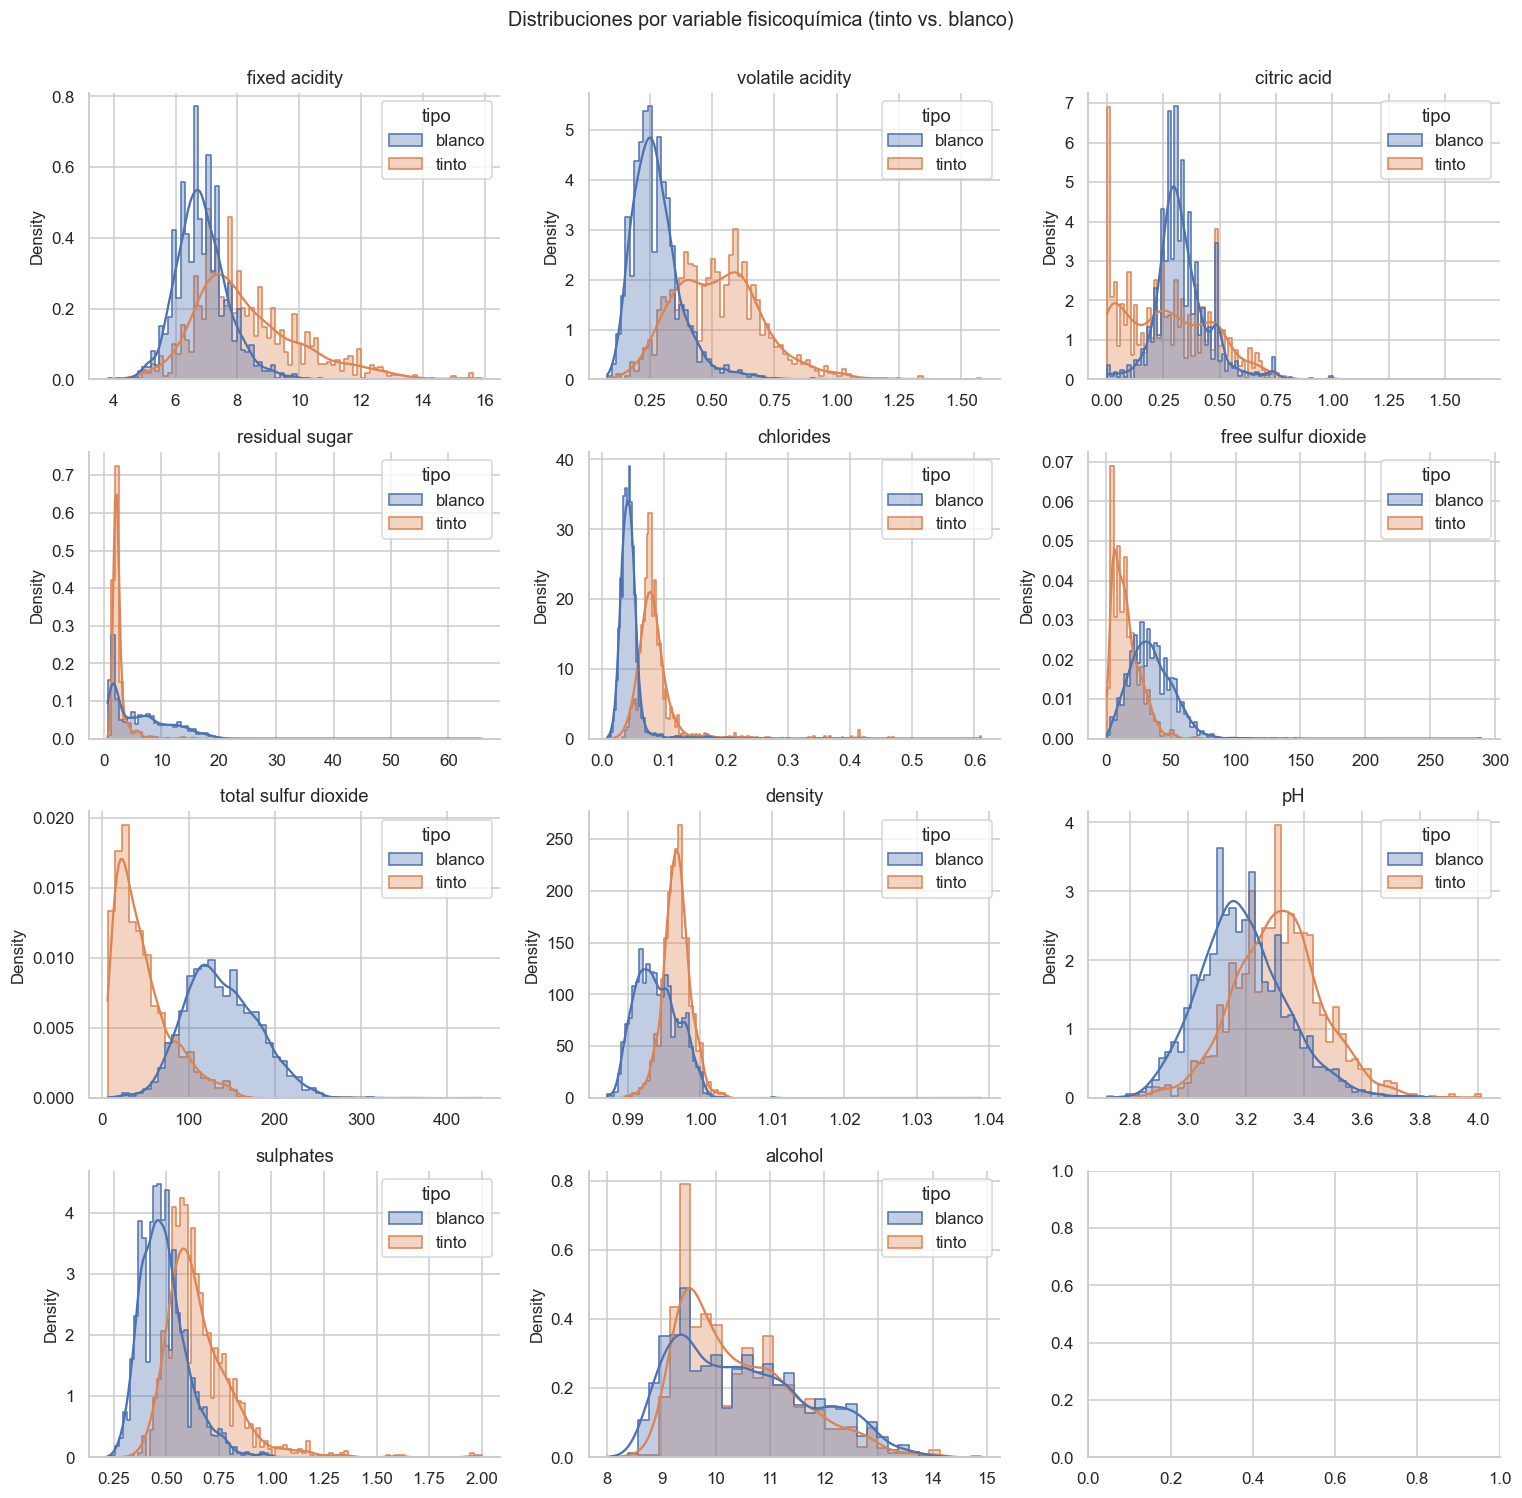

In [105]:
n_vars = len(VARS_FQ)
n_cols = 3
n_filas = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 3.4 * n_filas))
axes = axes.flat

for ax, var in zip(axes, VARS_FQ):
    sns.histplot(
        data=vinos, x=var, hue="tipo",
        kde=True, stat="density", common_norm=False,
        element="step", alpha=0.35, ax=ax,
    )
    ax.set_title(var)
    ax.set_xlabel("")

for ax in list(axes)[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Distribuciones por variable fisicoquímica (tinto vs. blanco)",
             fontsize=13, y=1.00)
fig.tight_layout()
guardar_figura("fig_u2_01_distribuciones")
plt.show()

#### 2.1.2b Histogramas con tendencia central y dispersión

Para cada variable fisicoquímica se superpone la **media** (línea verde punteada), las bandas de **±1 desviación estándar** (líneas moradas) y los extremos (**mínimo y máximo** en rojo). La caja de estadísticos complementa la tabla de la sección anterior con una lectura visual directa de la dispersión de cada atributo.

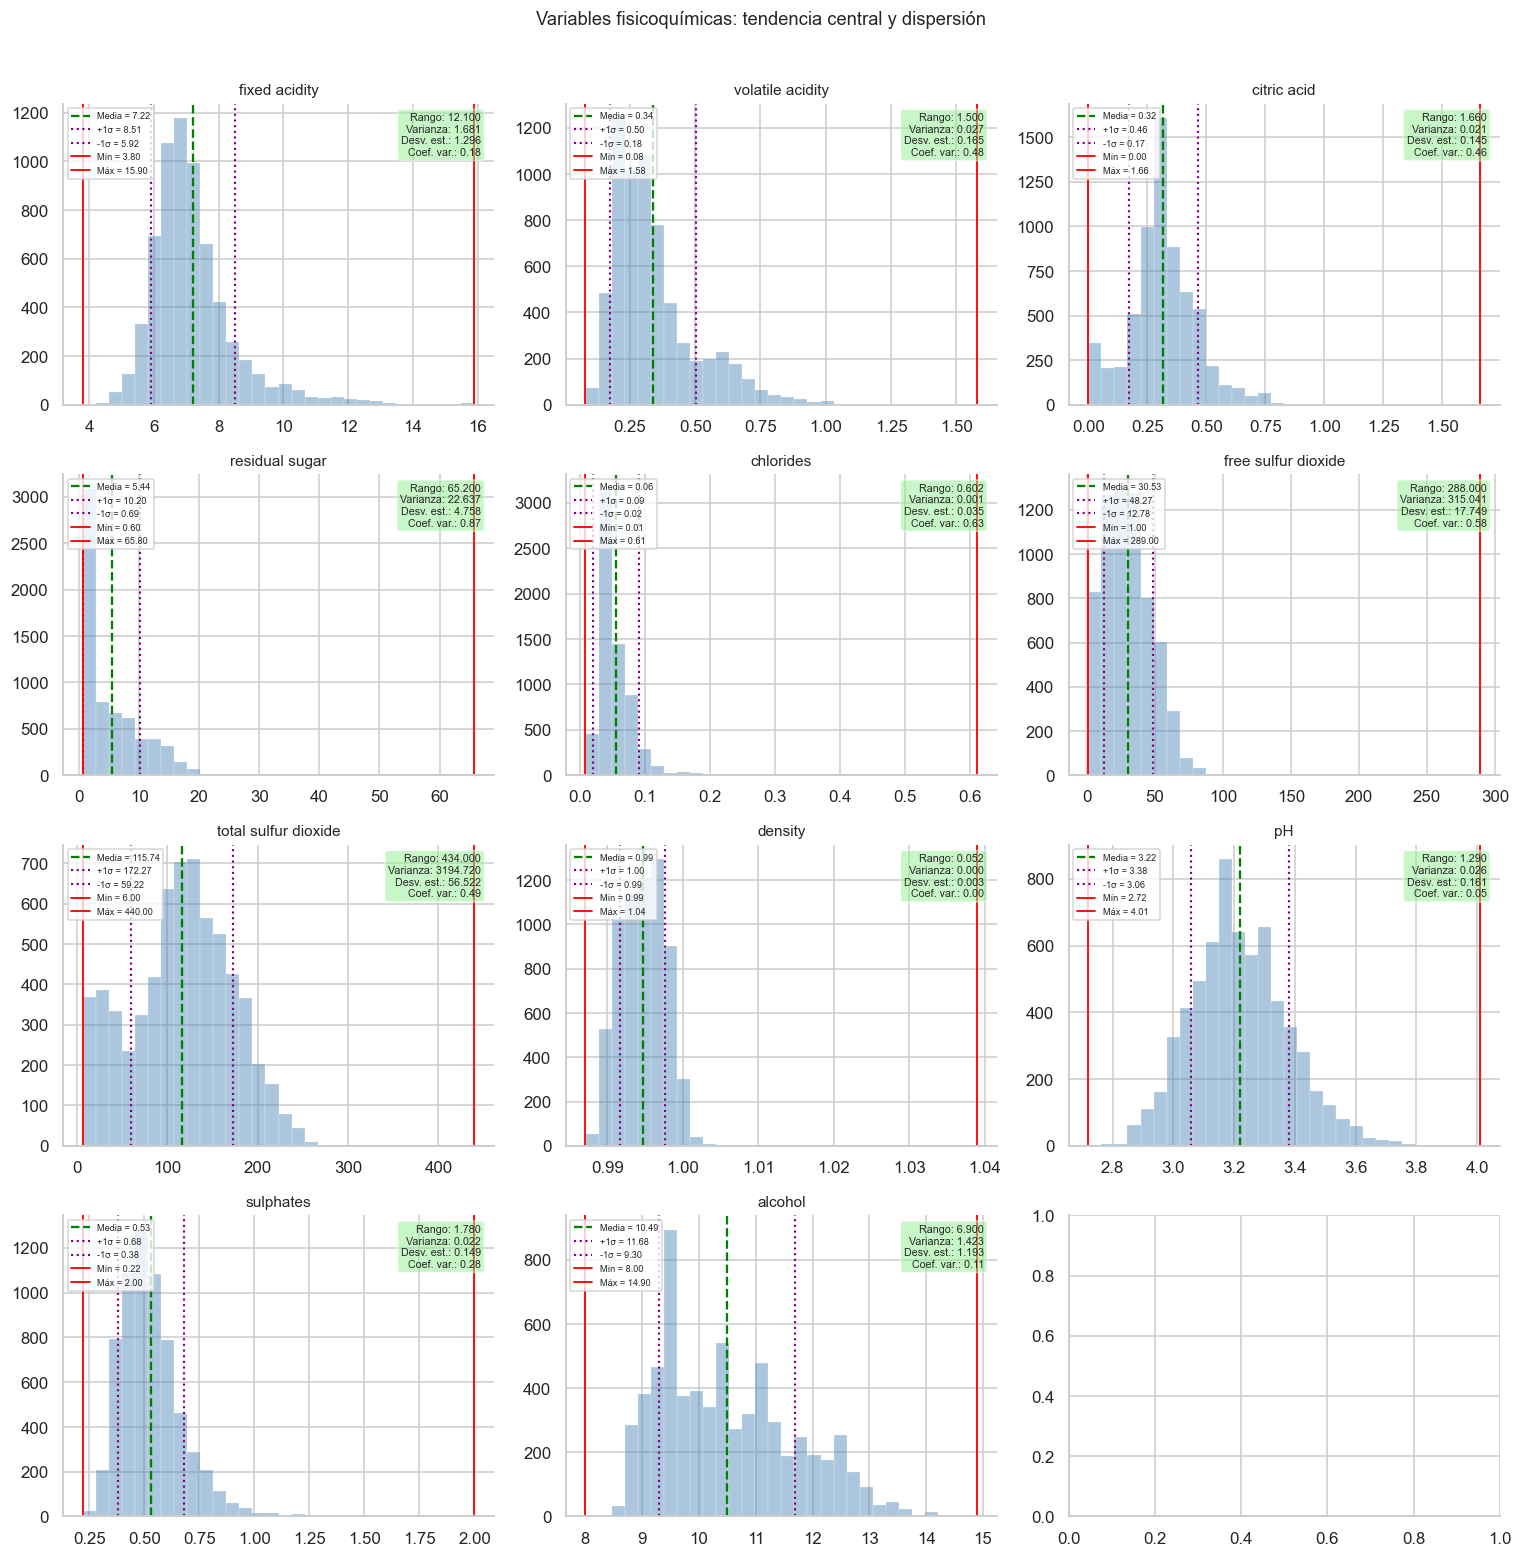

In [106]:
fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 3.5 * n_filas))
axes = axes.flat

for ax, var in zip(axes, VARS_FQ):
    data = vinos[var].dropna()
    media = data.mean()
    std   = data.std()
    vmin, vmax = data.min(), data.max()

    ax.hist(data, bins=30, color="steelblue", alpha=0.45, edgecolor="white", linewidth=0.3)
    ax.axvline(media,       color="green",  linestyle="--", linewidth=1.5, label=f"Media = {media:.2f}")
    ax.axvline(media + std, color="purple", linestyle=":",  linewidth=1.4, label=f"+1σ = {media+std:.2f}")
    ax.axvline(media - std, color="purple", linestyle=":",  linewidth=1.4, label=f"-1σ = {media-std:.2f}")
    ax.axvline(vmin,        color="red",    linestyle="-",  linewidth=1.2, label=f"Mín = {vmin:.2f}")
    ax.axvline(vmax,        color="red",    linestyle="-",  linewidth=1.2, label=f"Máx = {vmax:.2f}")

    stats_txt = (
        f"Rango: {vmax - vmin:.3f}" + chr(10)
        + f"Varianza: {data.var():.3f}" + chr(10)
        + f"Desv. est.: {std:.3f}" + chr(10)
        + f"Coef. var.: {std / media:.2f}"
    )
    ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=7, va="top", ha="right",
            bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.5))

    ax.set_title(var, fontsize=10)
    ax.set_xlabel("")
    ax.legend(fontsize=6, loc="upper left")

for ax in list(axes)[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Variables fisicoquímicas: tendencia central y dispersión", fontsize=12, y=1.01)
fig.tight_layout()
guardar_figura("fig_u2_01b_hist_dispersion")
plt.show()

#### 2.1.2c Distribuciones con percentiles y cuartiles

Se marcan los percentiles clave **P10, P25 (Q1), P50 (Mediana), P75 (Q3) y P90**, más los **nueve deciles** en gris claro. Esta visualización permite leer directamente la concentración central, la simetría y la amplitud de las colas de cada variable.

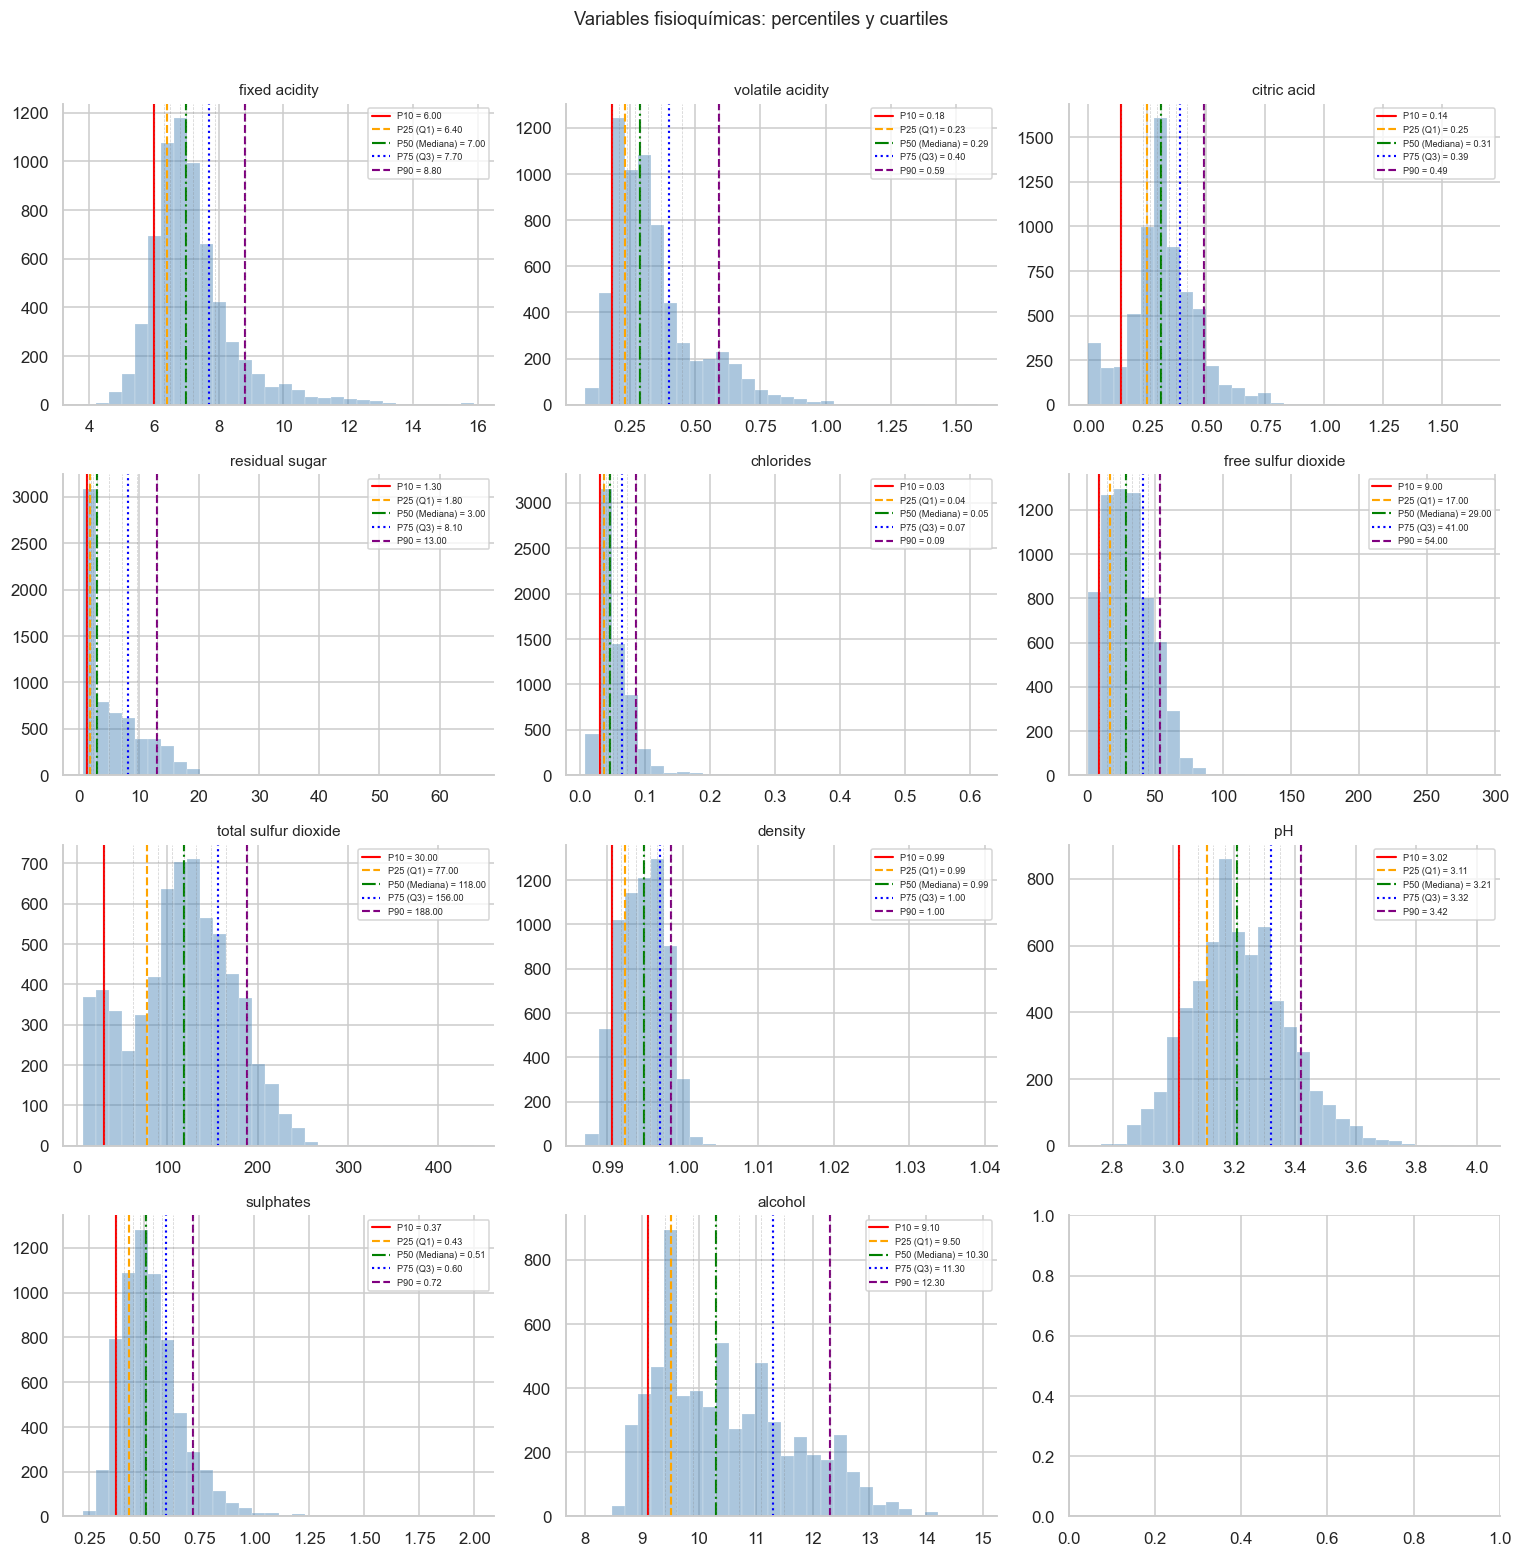

In [ ]:
fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 3.5 * n_filas))
axes = axes.flat

_pcts    = [0.10,  0.25,         0.50,             0.75,         0.90]
_colores = ["red", "orange",     "green",           "blue",       "purple"]
_estilos = ["-",   "--",         "-.",              ":",          "--"]
_etiqts  = ["P10", "P25 (Q1)", "P50 (Mediana)", "P75 (Q3)", "P90"]

for ax, var in zip(axes, VARS_FQ):
    data = vinos[var].dropna()

    ax.hist(data, bins=30, color="steelblue", alpha=0.45, edgecolor="white", linewidth=0.3)

    for p, col, est, etiq in zip(_pcts, _colores, _estilos, _etiqts):
        val = data.quantile(p)
        ax.axvline(val, color=col, linestyle=est, linewidth=1.4, label=f"{etiq} = {val:.2f}")

    for d in range(1, 10):
        ax.axvline(data.quantile(d / 10), color="gray", linestyle="--",
                   linewidth=0.5, alpha=0.35)

    ax.set_title(var, fontsize=10)
    ax.set_xlabel("")
    ax.legend(fontsize=6)

for ax in list(axes)[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Variables fisicoquímicas: percentiles y cuartiles", fontsize=12, y=1.01)
fig.tight_layout()
guardar_figura("fig_u2_01c_percentiles")
plt.show()

#### 2.1.3 Boxplots por tipo de vino

Los diagramas de caja resumen las cinco medidas de posición (mín., Q1, mediana, Q3, máx.) y exponen la presencia de valores extremos. Aquí la inspección es **preliminar**; el tratamiento formal de atípicos se aborda en la Unidad 3.

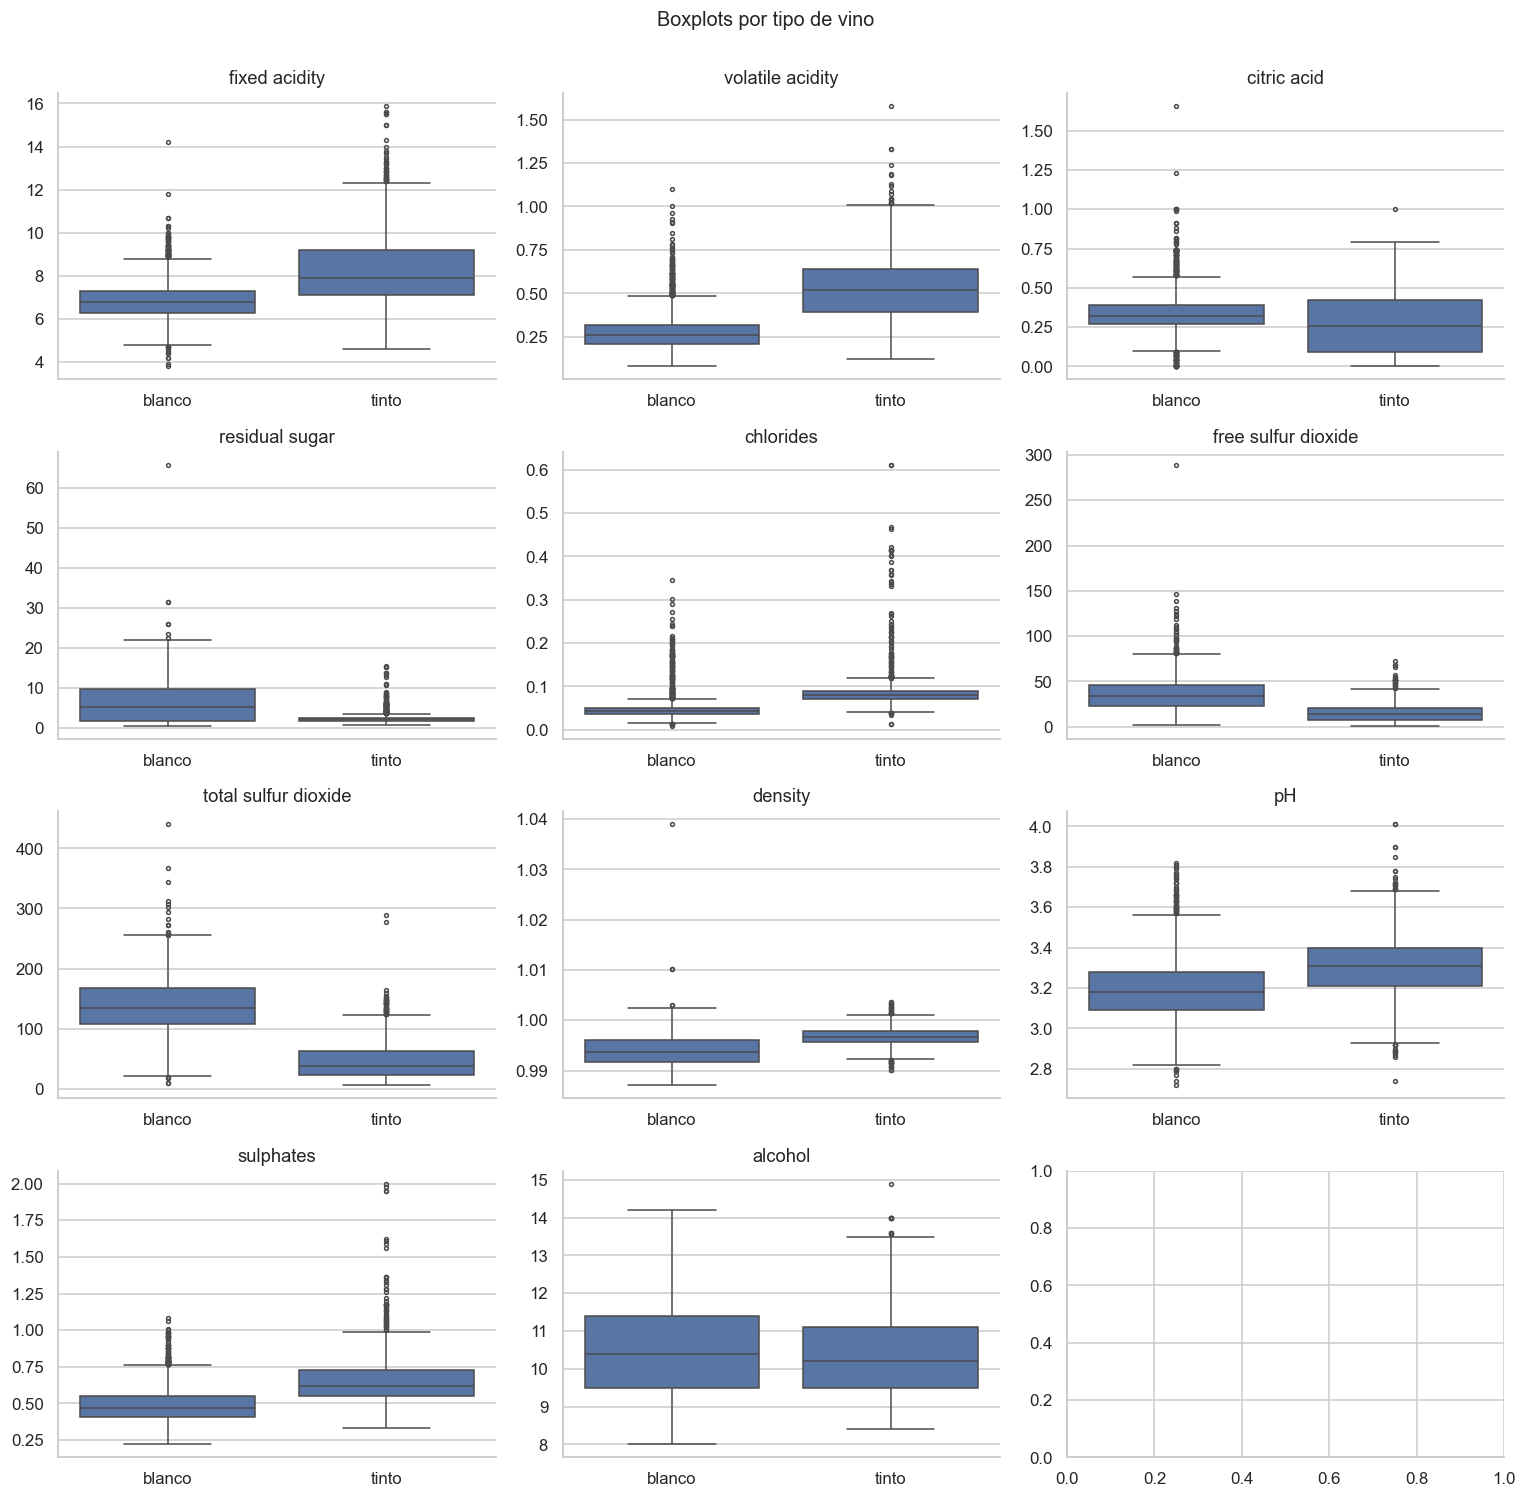

In [108]:
fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 3.4 * n_filas))
axes = axes.flat

for ax, var in zip(axes, VARS_FQ):
    sns.boxplot(data=vinos, x="tipo", y=var, ax=ax,
                showfliers=True, fliersize=2.5)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in list(axes)[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Boxplots por tipo de vino", fontsize=13, y=1.00)
fig.tight_layout()
guardar_figura("fig_u2_02_boxplots_tipo")
plt.show()

#### 2.1.4 Variable objetivo: `quality`

`quality` es ordinal y toma valores enteros entre 0 y 10. Antes de cualquier análisis bivariado conviene visualizar su distribución y comprobar el grado de **desbalance** entre clases.

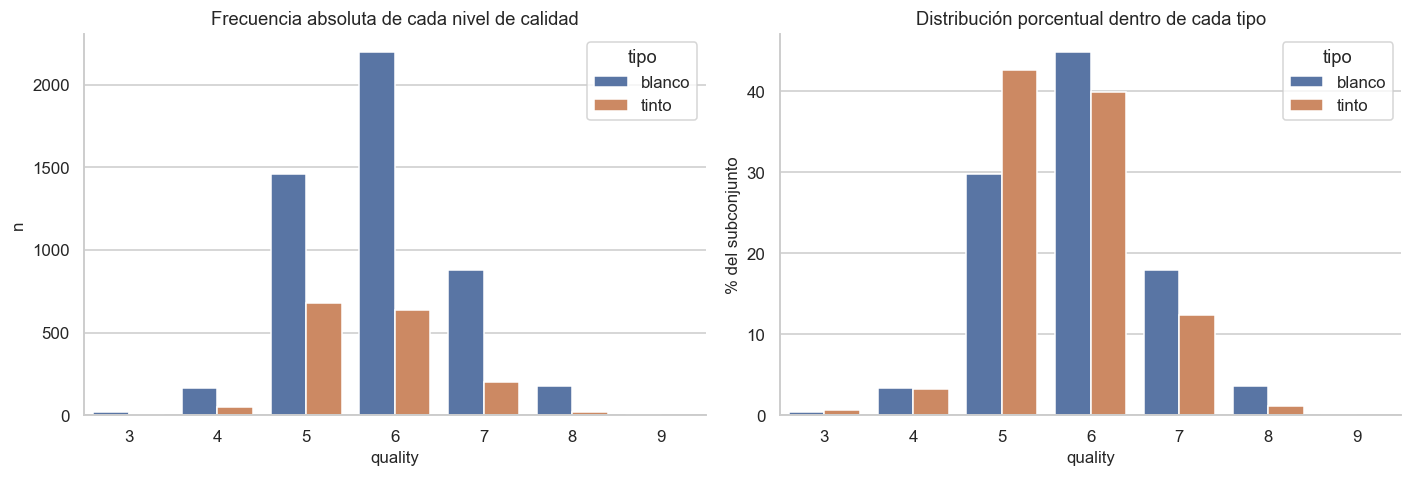

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=vinos, x="quality", hue="tipo", ax=axes[0])
axes[0].set_title("Frecuencia absoluta de cada nivel de calidad")
axes[0].set_ylabel("n")

(
    vinos.groupby("tipo", observed=True)["quality"]
         .value_counts(normalize=True)
         .mul(100).round(2)
         .rename("porcentaje")
         .reset_index()
         .pipe(lambda d: sns.barplot(data=d, x="quality", y="porcentaje",
                                     hue="tipo", ax=axes[1]))
)
axes[1].set_title("Distribución porcentual dentro de cada tipo")
axes[1].set_ylabel("% del subconjunto")

fig.tight_layout()
guardar_figura("fig_u2_03_quality_dist")
plt.show()

### 2.2 Análisis bivariado

El análisis bivariado examina la relación entre **pares de variables**. Empleamos:

- **Coeficiente de Pearson ($r$):** relación **lineal** entre variables continuas.
- **Coeficiente de Spearman ($\rho$):** relación **monótona**; adecuado cuando una variable es ordinal (`quality`) o hay no linealidad.
- **Comparación de medias por tipo:** boxplots con diferencia de medias anotada para identificar divergencias estructurales entre tinto y blanco.
- **Prueba $\chi^2$ de independencia:** asociación entre `tipo` y `quality` discretizada.

#### 2.2.1 Matrices de correlación (Pearson y Spearman)

Calculamos ambas matrices sobre el conjunto unificado para contrastar la estructura **lineal** y la **monótona**. Diferencias notables entre ambas matrices son síntoma de relaciones no lineales.

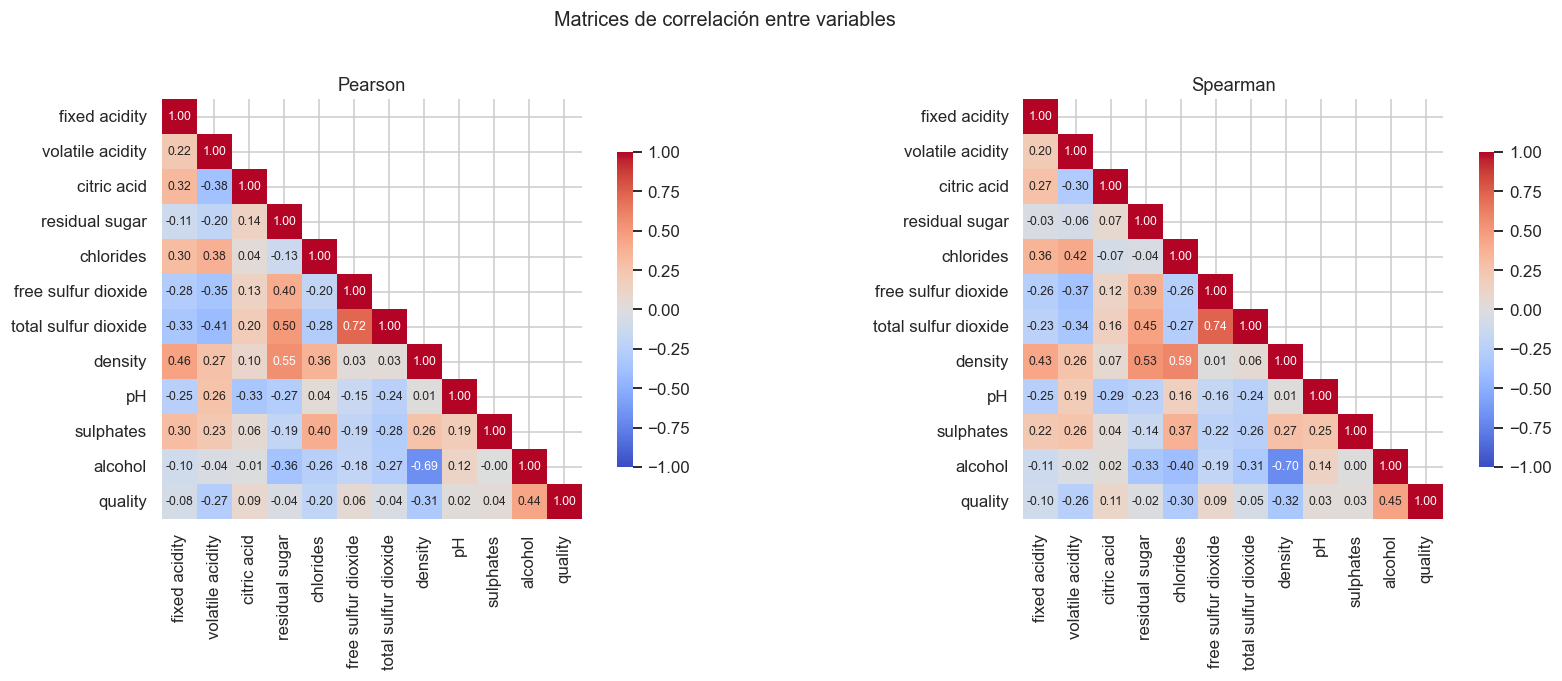

In [110]:
cols_num = VARS_FQ + ["quality"]
corr_pearson = vinos[cols_num].corr(method="pearson")
corr_spearman = vinos[cols_num].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mascara = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)

for ax, matriz, titulo in zip(
    axes,
    [corr_pearson, corr_spearman],
    ["Pearson", "Spearman"],
):
    sns.heatmap(matriz, mask=mascara, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, vmin=-1, vmax=1,
                square=True, cbar_kws={"shrink": 0.75},
                annot_kws={"size": 8}, ax=ax)
    ax.set_title(titulo)

fig.suptitle("Matrices de correlación entre variables", fontsize=13, y=1.02)
fig.tight_layout()
guardar_figura("fig_u2_04_correlaciones")
plt.show()

#### 2.2.2 Relación de cada variable fisicoquímica con `quality`

Dado que `quality` es ordinal, el coeficiente más adecuado es el de **Spearman**. Ordenamos las variables por la magnitud de su asociación monótona con la calidad para identificar las candidatas más prometedoras como predictoras.

In [111]:
ranking_quality = (
    corr_spearman["quality"]
        .drop("quality")
        .to_frame("ρ_spearman")
        .assign(**{"r_pearson": corr_pearson["quality"].drop("quality")})
        .assign(**{"|ρ|": lambda d: d["ρ_spearman"].abs()})
        .sort_values("|ρ|", ascending=False)
)
ranking_quality

,ρ_spearman,r_pearson,|ρ|
alcohol,0.4469,0.4443,0.4469
density,-0.3228,-0.3059,0.3228
chlorides,-0.2951,-0.2007,0.2951
volatile acidity,-0.2578,-0.2657,0.2578
citric acid,0.1057,0.0855,0.1057
fixed acidity,-0.0982,-0.0767,0.0982
free sulfur dioxide,0.0869,0.0555,0.0869
total sulfur dioxide,-0.0548,-0.0414,0.0548
pH,0.0325,0.0195,0.0325
sulphates,0.0298,0.0385,0.0298


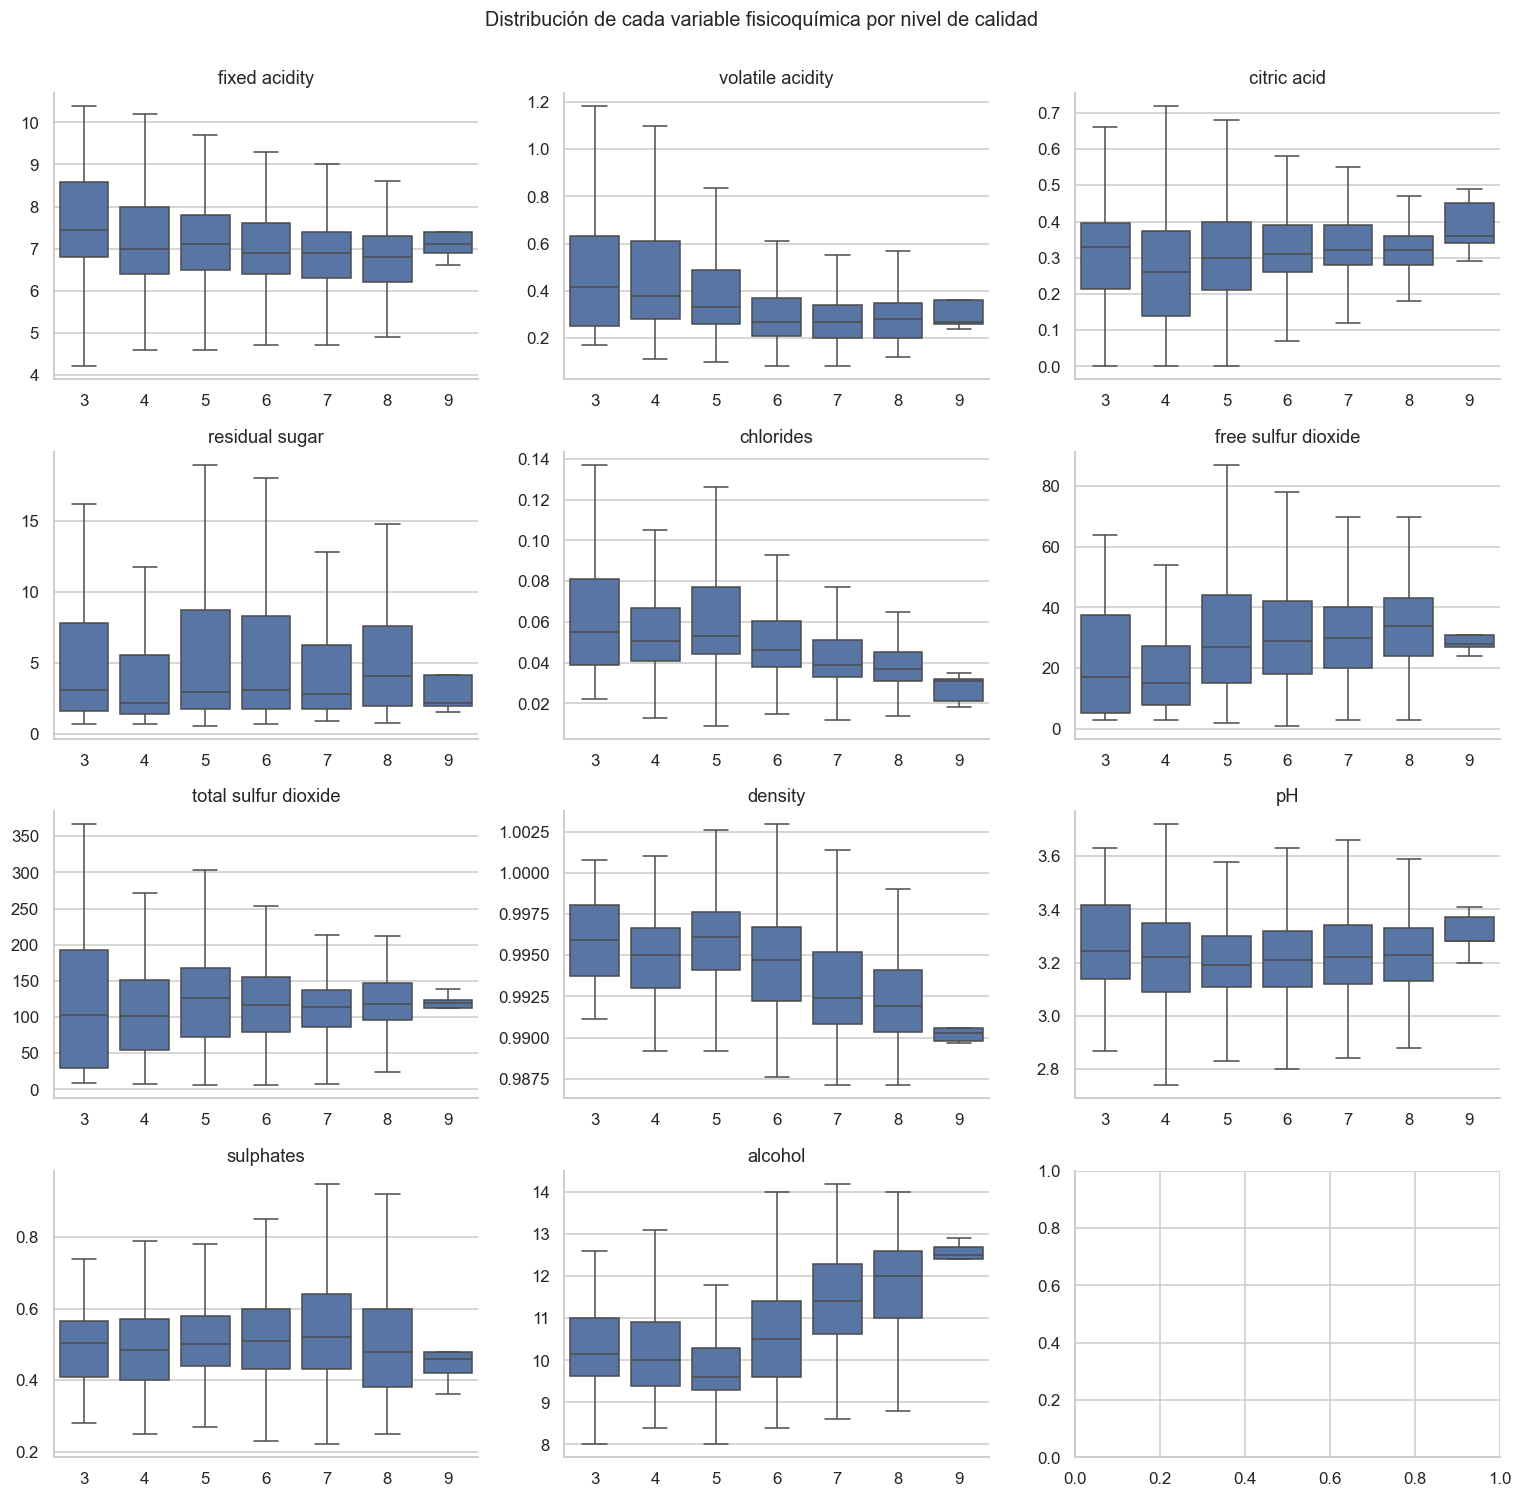

In [112]:
# Visualización: boxplots de cada variable agrupados por nivel de quality.
fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 3.4 * n_filas))
axes = axes.flat

orden_q = sorted(vinos["quality"].unique())

for ax, var in zip(axes, VARS_FQ):
    sns.boxplot(data=vinos, x="quality", y=var, order=orden_q,
                ax=ax, showfliers=False, color="#4C72B0")
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in list(axes)[len(VARS_FQ):]:
    ax.set_visible(False)

fig.suptitle("Distribución de cada variable fisicoquímica por nivel de calidad",
             fontsize=13, y=1.00)
fig.tight_layout()
guardar_figura("fig_u2_05_vars_vs_quality")
plt.show()

#### 2.2.3 Comparación tinto vs. blanco

Para cada variable fisicoquímica comparamos visualmente las distribuciones de tinto y blanco mediante **boxplots** acompañados de la **diferencia de medias** anotada. Este contraste permite identificar qué atributos presentan mayor divergencia estructural entre los dos subconjuntos, información relevante para interpretar los resultados del EDA y las decisiones de preprocesamiento posteriores.

C:\Users\Camilo\AppData\Local\Temp\ipykernel_181712\3600729887.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Camilo\AppData\Local\Temp\ipykernel_181712\3600729887.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Camilo\AppData\Local\Temp\ipykernel_181712\3600729887.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Camilo\AppData\Local\Temp\ipykernel_181712\3600729887.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

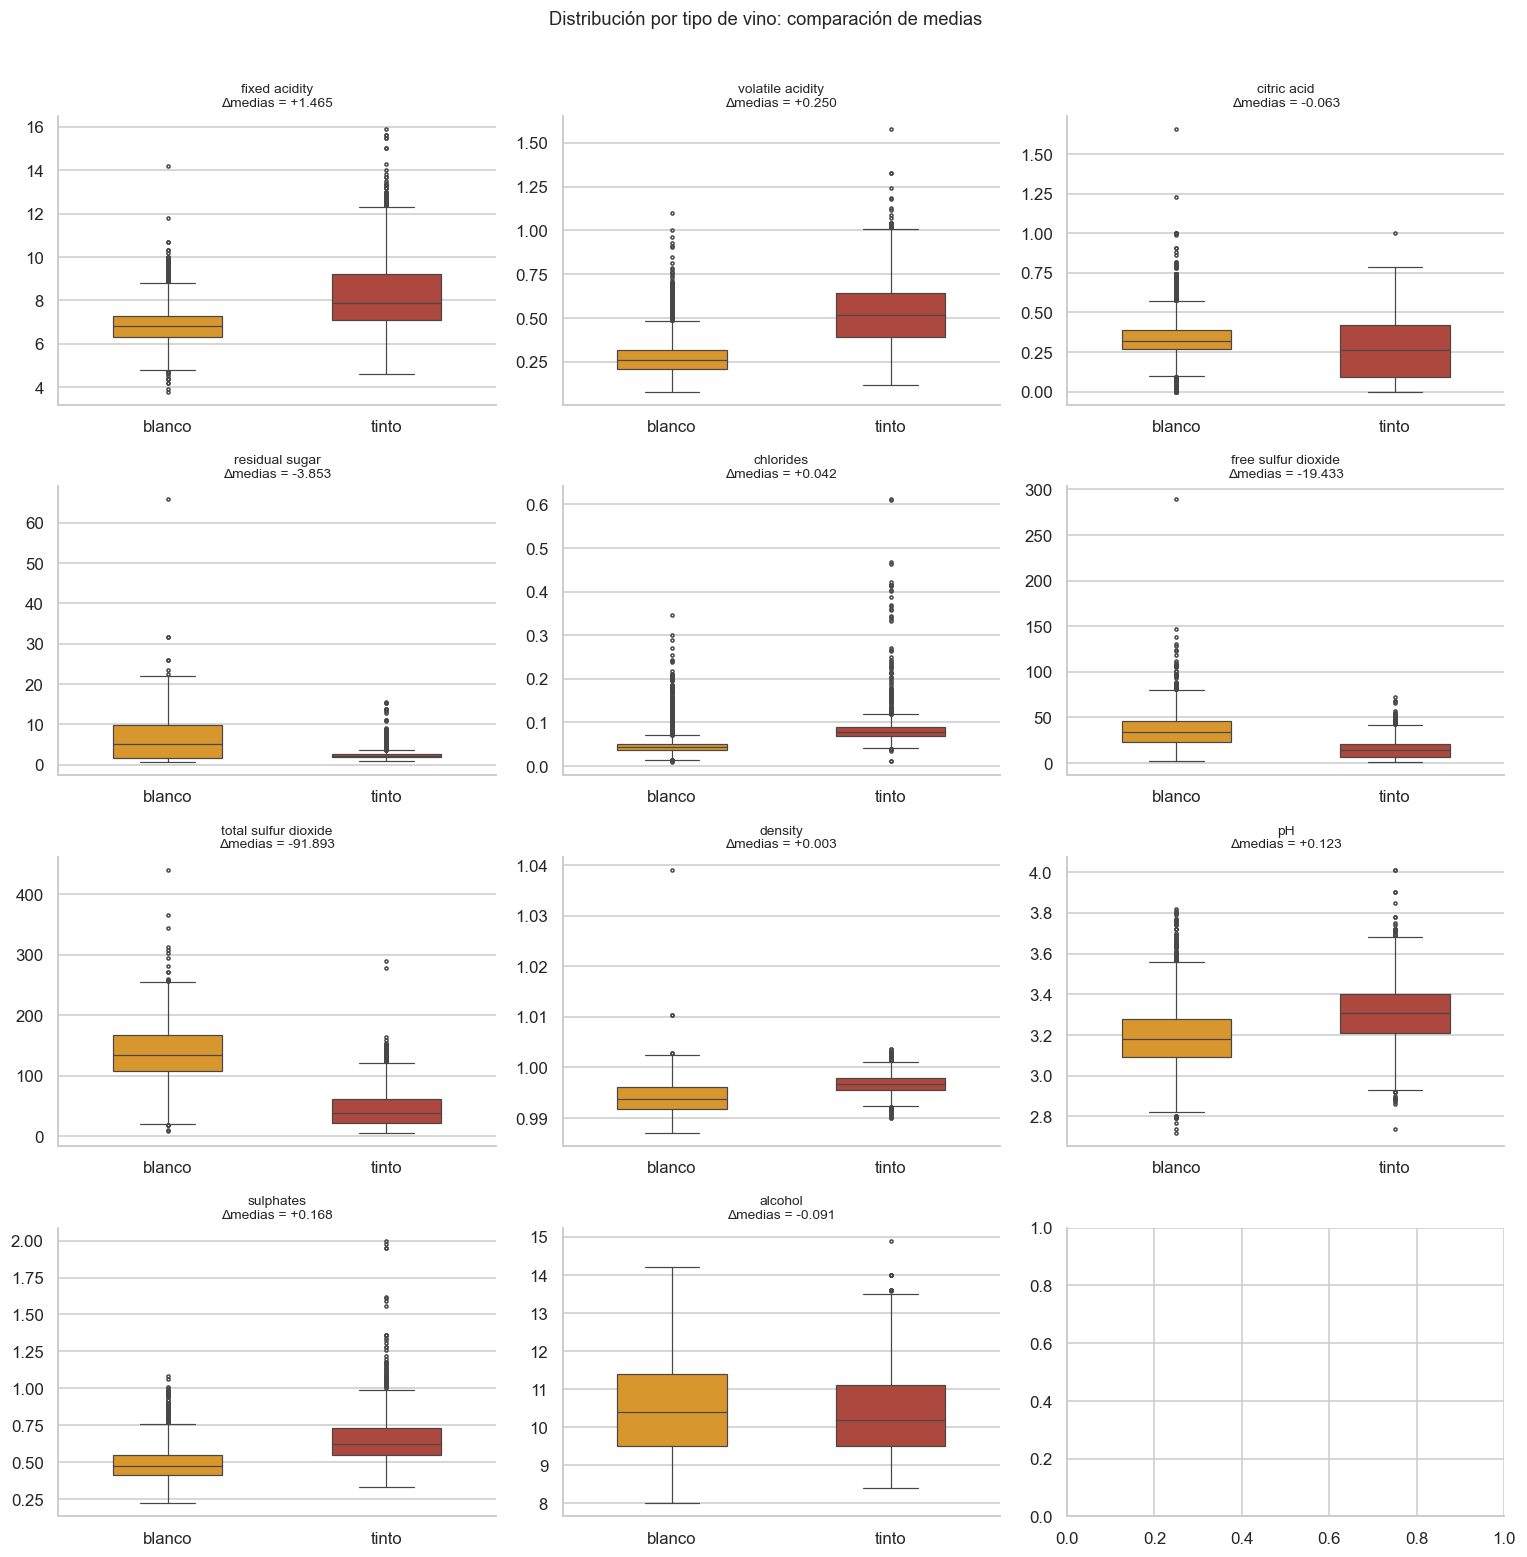

In [113]:
fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 3.5 * n_filas))
axes = axes.flat

for ax, var in zip(axes, VARS_FQ):
    sns.boxplot(
        data=vinos, x="tipo", y=var, ax=ax,
        palette={"tinto": "#c0392b", "blanco": "#f39c12"},
        width=0.5, fliersize=2, linewidth=0.8,
    )
    media_t = vinos.loc[vinos["tipo"] == "tinto",  var].mean()
    media_b = vinos.loc[vinos["tipo"] == "blanco", var].mean()
    dif = media_t - media_b
    ax.set_title(f"{var}" + chr(10) + f"Δmedias = {dif:+.3f}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in list(axes)[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Distribución por tipo de vino: comparación de medias", fontsize=12, y=1.01)
fig.tight_layout()
guardar_figura("fig_u2_03_comparacion_tipo")
plt.show()

#### 2.2.4 Asociación entre `tipo` y `quality` ($\chi^2$)

`tipo` es nominal y `quality` es ordinal. La prueba $\chi^2$ de independencia evalúa si la distribución de calidades difiere entre tinto y blanco.

> **Supuesto.** $\chi^2$ requiere que **todas las frecuencias esperadas sean $\geq 5$**. Las clases extremas de `quality` (3 y 9) tienen muy pocas observaciones, por lo que agrupamos `quality` en tres bandas ordenadas que conservan el orden y satisfacen el supuesto: *baja* (3–4), *media* (5–6) y *alta* (7–9). Como medida del tamaño del efecto reportamos la **V de Cramér**.

In [114]:
from scipy.stats import chi2_contingency

# Discretización ordinal de quality (no modifica el DataFrame original).
banda_quality = vinos["quality"].map(
    lambda q: "baja (3-4)" if q <= 4 else ("media (5-6)" if q <= 6 else "alta (7-9)")
)

tabla_contingencia = pd.crosstab(vinos["tipo"], banda_quality)
tabla_contingencia = tabla_contingencia[["baja (3-4)", "media (5-6)", "alta (7-9)"]]

chi2, p_chi2, gl, esperadas = chi2_contingency(tabla_contingencia)

n = tabla_contingencia.values.sum()
k = min(tabla_contingencia.shape) - 1
cramer_v = (chi2 / (n * k)) ** 0.5

print("Tabla de contingencia (frecuencias observadas):")
print(tabla_contingencia)
print(f"\nFrecuencia esperada mínima: {esperadas.min():.1f}  (debe ser >= 5)")
print(f"\nchi^2 = {chi2:.3f}   gl = {gl}   p-valor = {p_chi2:.3e}")
print(f"V de Cramer = {cramer_v:.3f}  "
      f"(0 = sin asociacion; 1 = asociacion perfecta)")

Tabla de contingencia (frecuencias observadas):
quality  baja (3-4)  media (5-6)  alta (7-9)
tipo                                        
blanco          183         3655        1060
tinto            63         1319         217

Frecuencia esperada mínima: 60.5  (debe ser >= 5)

chi^2 = 49.823   gl = 2   p-valor = 1.517e-11
V de Cramer = 0.088  (0 = sin asociacion; 1 = asociacion perfecta)


### 2.3 Análisis multivariado

Aplicamos **Análisis de Componentes Principales (PCA)** para estudiar relaciones simultáneas entre las 11 variables fisicoquímicas. Las variables se estandarizan previamente (`StandardScaler`) para evitar que las de mayor varianza dominen los componentes.

In [115]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = vinos[VARS_FQ].values
y_quality = vinos["quality"].values
y_tipo = vinos["tipo"].values

X_std = StandardScaler().fit_transform(X)

pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_std)

varianza = pca.explained_variance_ratio_
varianza_acum = varianza.cumsum()

resumen_pca = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(varianza))],
    "varianza_explicada": varianza,
    "varianza_acumulada": varianza_acum,
})
resumen_pca

,componente,varianza_explicada,varianza_acumulada
0,PC1,0.2754,0.2754
1,PC2,0.2267,0.5022
2,PC3,0.1415,0.6436
3,PC4,0.0882,0.7319
4,PC5,0.0654,0.7973
5,PC6,0.0552,0.8525
6,PC7,0.0476,0.9001
7,PC8,0.0456,0.9457
8,PC9,0.0306,0.9763
9,PC10,0.0207,0.9970


#### 2.3.1 Varianza explicada (scree plot)

El *scree plot* permite decidir cuántos componentes retener. Un criterio frecuente es conservar los componentes que en conjunto expliquen al menos el **70–80 %** de la varianza.

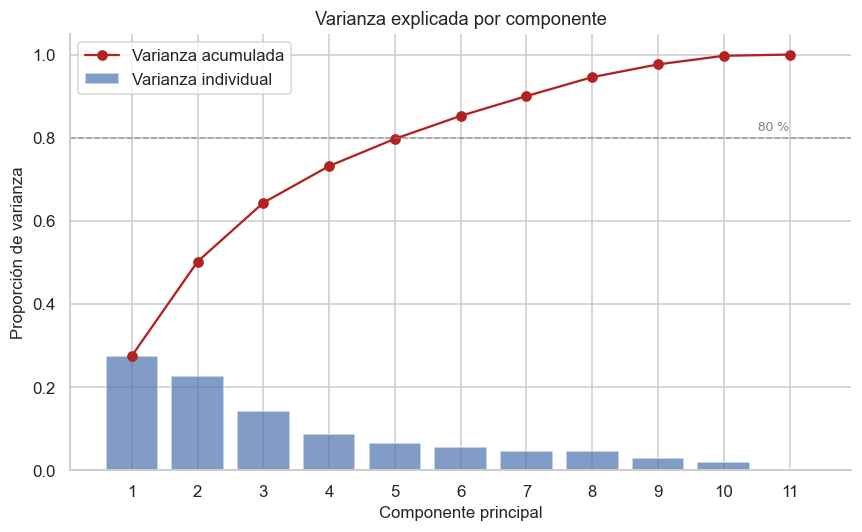

In [116]:
fig, ax = plt.subplots(figsize=(8, 5))
componentes = np.arange(1, len(varianza) + 1)

ax.bar(componentes, varianza, alpha=0.7, label="Varianza individual")
ax.plot(componentes, varianza_acum, marker="o", color="firebrick",
        label="Varianza acumulada")

ax.axhline(0.80, ls="--", color="gray", lw=1, alpha=0.7)
ax.text(len(varianza), 0.81, "80 %", color="gray",
        ha="right", va="bottom", fontsize=9)

ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporción de varianza")
ax.set_title("Varianza explicada por componente")
ax.set_xticks(componentes)
ax.legend()

fig.tight_layout()
guardar_figura("fig_u2_06_pca_varianza")
plt.show()

#### 2.3.2 Proyección sobre el plano PC1–PC2

Visualizamos las observaciones en el plano definido por los dos primeros componentes, coloreando primero por `tipo` (¿se separan tinto y blanco en el espacio reducido?) y luego por `quality` (¿hay un gradiente asociado a la calidad?).

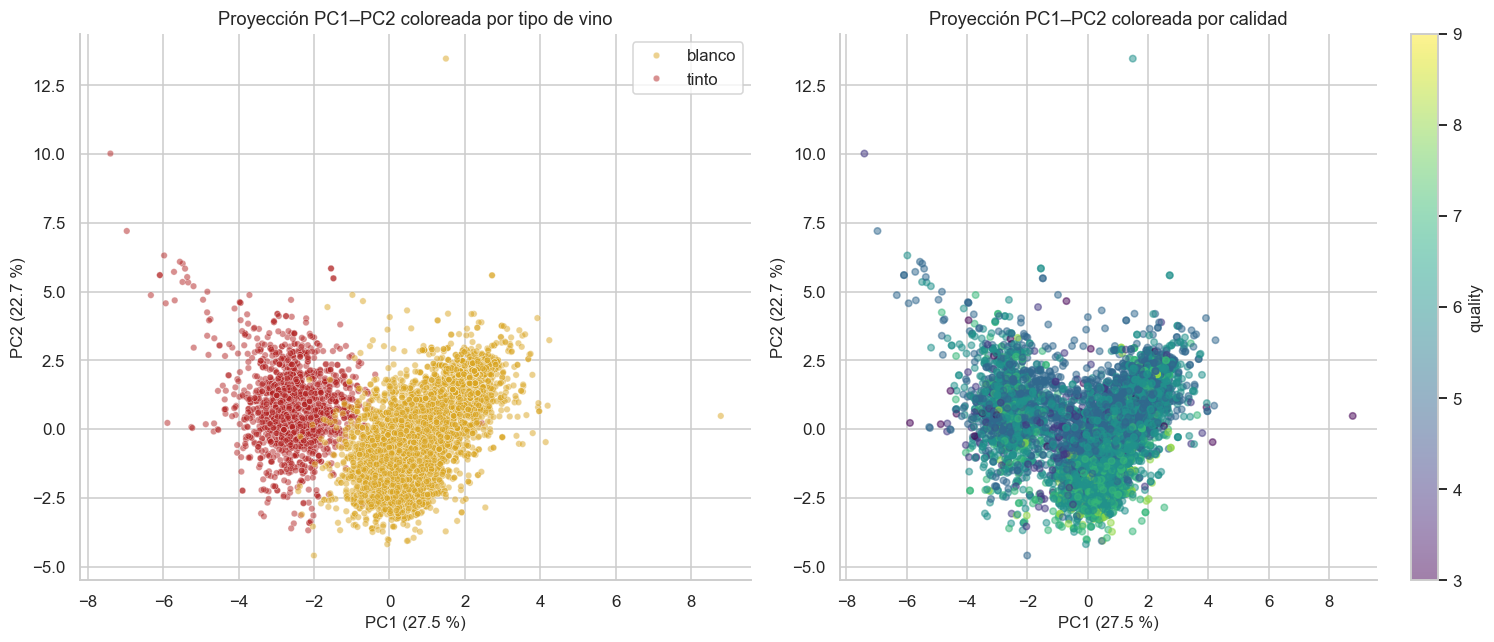

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Coloreado por tipo
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=y_tipo, alpha=0.5, s=18,
                palette={"tinto": "#B22222", "blanco": "#DAA520"},
                ax=axes[0])
axes[0].set_title("Proyección PC1–PC2 coloreada por tipo de vino")
axes[0].set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
axes[0].set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")

# Coloreado por quality
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=y_quality, cmap="viridis", alpha=0.5, s=18)
axes[1].set_title("Proyección PC1–PC2 coloreada por calidad")
axes[1].set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
axes[1].set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
plt.colorbar(sc, ax=axes[1], label="quality")

fig.tight_layout()
guardar_figura("fig_u2_07_pca_scatter")
plt.show()

#### 2.3.3 Cargas factoriales y biplot

Las **cargas** (componentes de los autovectores) indican el peso de cada variable original sobre cada componente principal. El *biplot* superpone la nube de observaciones con los vectores de carga, facilitando la interpretación de la dirección de cada componente.

In [118]:
cargas = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=VARS_FQ,
)
cargas[["PC1", "PC2", "PC3"]].round(3)

,PC1,PC2,PC3
fixed acidity,-0.2390,0.3360,0.4340
volatile acidity,-0.3810,0.1180,-0.3070
citric acid,0.1520,0.1830,0.5910
residual sugar,0.3460,0.3300,-0.1650
chlorides,-0.2900,0.3150,-0.0170
free sulfur dioxide,0.4310,0.0720,-0.1340
total sulfur dioxide,0.4870,0.0870,-0.1070
density,-0.0450,0.5840,-0.1760
pH,-0.2190,-0.1560,-0.4550
sulphates,-0.2940,0.1920,0.0700


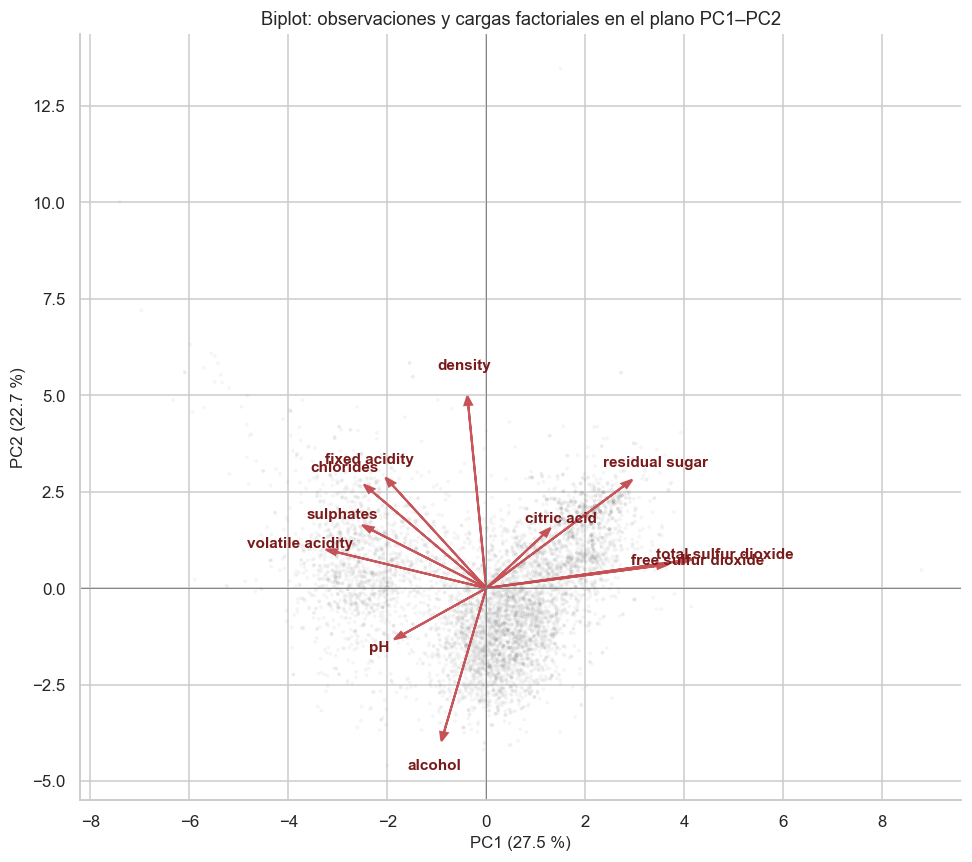

In [119]:
# Biplot: scatter de observaciones (fondo tenue) + flechas de cargas en PC1-PC2.
fig, ax = plt.subplots(figsize=(9, 8))

# Fondo muy discreto para no competir con las flechas
ax.scatter(X_pca[:, 0], X_pca[:, 1],
           c="#888888", alpha=0.08, s=6, edgecolors="none")

escala = 1.15 * max(abs(X_pca[:, 0]).max(), abs(X_pca[:, 1]).max())
escala_flecha = escala * 0.55

for var, (pc1, pc2) in zip(VARS_FQ, pca.components_[:2].T):
    ax.arrow(0, 0, pc1 * escala_flecha, pc2 * escala_flecha,
             color="#C44E52", alpha=0.95, head_width=0.15, lw=1.4,
             length_includes_head=True)
    ax.text(pc1 * escala_flecha * 1.16, pc2 * escala_flecha * 1.16,
            var, color="#7A1A1A", fontsize=10, ha="center", va="center",
            fontweight="bold")

ax.axhline(0, color="gray", lw=0.6)
ax.axvline(0, color="gray", lw=0.6)
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
ax.set_title("Biplot: observaciones y cargas factoriales en el plano PC1–PC2")

fig.tight_layout()
guardar_figura("fig_u2_08_pca_biplot")
plt.show()

### 2.4 Síntesis de hallazgos del EDA


**Univariado.**
- `residual sugar`, `chlorides` y `sulphates` presentan asimetría positiva marcada ($s > 1$), lo que motiva transformaciones Yeo–Johnson en la Unidad 4. `density` y `pH` son aproximadamente simétricas.
- `quality` está concentrada en los niveles 5–6; las clases extremas (3, 4, 8, 9) son muy escasas, un caso típico de **desbalance ordinal**.

**Bivariado.**
- `alcohol` presenta la mayor asociación monótona con `quality` ($\rho \approx 0{,}45$); le siguen `density` ($\rho \approx -0{,}32$), `chlorides` ($\rho \approx -0{,}30$) y `volatile acidity` ($\rho \approx -0{,}26$), patrón consistente con Cortez et al. (2009).
- La comparación por tipo revela diferencias estructurales marcadas en `total sulfur dioxide`, `volatile acidity`, `free sulfur dioxide` y `chlorides`.
- La prueba $\chi^2$ confirma asociación significativa entre `tipo` y `quality`, con tamaño del efecto **pequeño** (V de Cramér): el tipo influye pero no determina la calidad.

**Multivariado.**
- La varianza se distribuye uniformemente entre componentes: PC1 explica el 27,5 % y se requieren cinco para alcanzar el 80 %. PC1 separa tinto de blanco ($\mathrm{SO}_2$, azúcar vs. acidez volátil, cloruros); PC2 captura el contraste densidad–alcohol.
- El gradiente de `quality` en el plano PC1–PC2 es **difuso**, lo que anticipa la necesidad de modelos no lineales para predecirla.

---

## 3. Detección y tratamiento de datos atípicos (Unidad 3)

Los **datos atípicos** (*outliers*) son observaciones que se apartan notablemente del comportamiento general del resto de los datos. Su presencia puede sesgar coeficientes de correlación, distorsionar estadísticos sensibles a la escala (media, varianza, PCA) y comprometer las conclusiones de un análisis (Barnett & Lewis, 1994).

En esta unidad identificamos y documentamos los valores potencialmente atípicos del conjunto *Wine Quality* aplicando **tres familias de técnicas** correspondientes a las orientaciones de la rúbrica y de la sesión teórica:

| Familia | Técnicas aplicadas |
|---|---|
| **Métodos gráficos** | Diagramas de caja (`fig_u2_02_boxplots_tipo`, Unidad 2). |
| **Métodos estadísticos** | Regla del **rango intercuartílico (IQR)**; **puntaje Z** ($Z$-score). |
| **Aprendizaje automático** | **Isolation Forest**; **Local Outlier Factor (LOF)**. |

> **Sobre el alcance.** La rúbrica pide *identificar y documentar* los valores anómalos. En esta unidad **no se eliminan ni se imputan** observaciones: caracterizamos qué tantas, dónde y bajo qué criterio se detectan. La decisión de eliminación o imputación se ejecuta en la Unidad 4.

> **Nota metodológica.** La detección se realiza sobre el conjunto unificado (tinto + blanco) para mantener simplicidad y coherencia con las sesiones teóricas. Una opción más fina sería realizar la detección **por tipo**, dado que ambos subconjuntos difieren estructuralmente (Unidad 2); lo registramos como línea futura.

### 3.1 Detección univariada con métodos gráficos y estadísticos

Los métodos univariados examinan **una variable a la vez** y marcan como atípica toda observación cuyo valor caiga fuera de un rango definido a partir de estadísticos descriptivos.

#### 3.1.1 Inspección visual: diagramas de caja

Los boxplots de la Unidad 2 (`fig_u2_02_boxplots_tipo`) ya ofrecen una primera lectura de los atípicos univariados: los puntos dibujados más allá de los "bigotes" corresponden a observaciones cuyo valor excede $Q_3 + 1.5\,\mathrm{IQR}$ o cae por debajo de $Q_1 - 1.5\,\mathrm{IQR}$. Esta visualización guía la elección formal de los criterios cuantitativos que aplicamos a continuación.

#### 3.1.2 Regla del rango intercuartílico (IQR)

Una observación $x$ se considera atípica si

$$
x < Q_1 - 1.5\,\mathrm{IQR} \quad \text{o} \quad x > Q_3 + 1.5\,\mathrm{IQR},
$$

donde $\mathrm{IQR} = Q_3 - Q_1$. Es un criterio **robusto**: $Q_1$, $Q_3$ y la mediana son insensibles a los valores extremos, por lo que el método se desempeña bien en distribuciones asimétricas.

In [120]:
def detectar_iqr(serie, k=1.5):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - k * iqr
    lim_sup = q3 + k * iqr
    mascara = (serie < lim_inf) | (serie > lim_sup)
    return mascara, lim_inf, lim_sup


resumen_iqr = []
mascaras_iqr = pd.DataFrame(index=vinos.index)

for var in VARS_FQ:
    mascara, li, ls = detectar_iqr(vinos[var])
    mascaras_iqr[var] = mascara
    resumen_iqr.append({
        "variable": var,
        "Q1": vinos[var].quantile(0.25),
        "Q3": vinos[var].quantile(0.75),
        "lim_inf": li,
        "lim_sup": ls,
        "n_atipicos": int(mascara.sum()),
        "% atipicos": 100 * mascara.sum() / len(vinos),
    })

resumen_iqr = (pd.DataFrame(resumen_iqr)
                 .set_index("variable")
                 .sort_values("% atipicos", ascending=False))
resumen_iqr

,Q1,Q3,lim_inf,lim_sup,n_atipicos,% atipicos
variable,,,,,,
citric acid,0.2500,0.3900,0.0400,0.6000,509,7.8344
volatile acidity,0.2300,0.4000,-0.0250,0.6550,377,5.8027
fixed acidity,6.4000,7.7000,4.4500,9.6500,357,5.4948
chlorides,0.0380,0.0650,-0.0025,0.1055,286,4.4020
sulphates,0.4300,0.6000,0.1750,0.8550,191,2.9398
residual sugar,1.8000,8.1000,-7.6500,17.5500,118,1.8162
pH,3.1100,3.3200,2.7950,3.6350,73,1.1236
free sulfur dioxide,17.0000,41.0000,-19.0000,77.0000,62,0.9543
total sulfur dioxide,77.0000,156.0000,-41.5000,274.5000,10,0.1539


In [121]:
# Observaciones marcadas como atípicas por IQR en al menos una variable
atipicos_iqr_global = mascaras_iqr.any(axis=1)
print(f"Observaciones atípicas según IQR (en al menos 1 variable): "
      f"{atipicos_iqr_global.sum():,} de {len(vinos):,} "
      f"({100 * atipicos_iqr_global.mean():.2f} %)")

Observaciones atípicas según IQR (en al menos 1 variable): 1,473 de 6,497 (22.67 %)


#### 3.1.3 Puntaje Z (*Z-score*)

El puntaje Z estandariza cada valor respecto a la media y la desviación estándar:

$$
z_i = \frac{x_i - \bar{x}}{s_x}.
$$

Una observación se marca como atípica si $|z_i| > 3$, es decir, si está a más de 3 desviaciones estándar de la media. Es un criterio que **asume aproximada normalidad** y es sensible a la propia presencia de atípicos (la desviación estándar se infla). Por eso suele complementar —no sustituir— al IQR.

In [122]:
from scipy.stats import zscore

UMBRAL_Z = 3.0

z_scores = vinos[VARS_FQ].apply(zscore)
mascaras_z = z_scores.abs() > UMBRAL_Z

resumen_z = pd.DataFrame({
    "n_atipicos": mascaras_z.sum(),
    "% atipicos": 100 * mascaras_z.sum() / len(vinos),
}).sort_values("% atipicos", ascending=False)
resumen_z

,n_atipicos,% atipicos
fixed acidity,128,1.9701
chlorides,107,1.6469
volatile acidity,95,1.4622
sulphates,75,1.1544
free sulfur dioxide,36,0.5541
pH,33,0.5079
citric acid,28,0.4310
residual sugar,26,0.4002
total sulfur dioxide,8,0.1231
density,3,0.0462


In [123]:
atipicos_z_global = mascaras_z.any(axis=1)
print(f"Observaciones atípicas según Z-score (|z| > {UMBRAL_Z}, en al menos 1 variable): "
      f"{atipicos_z_global.sum():,} de {len(vinos):,} "
      f"({100 * atipicos_z_global.mean():.2f} %)")

Observaciones atípicas según Z-score (|z| > 3.0, en al menos 1 variable): 488 de 6,497 (7.51 %)


#### 3.1.4 Concordancia entre IQR y *Z-score*

Ambos criterios detectan información parcialmente distinta: el IQR es robusto y suele ser **más sensible** en presencia de asimetría, mientras que el *Z-score* identifica colas pesadas relativas a una referencia gaussiana. Comparamos el conteo por variable y la coincidencia a nivel de observación.

In [124]:
comparacion_uni = pd.DataFrame({
    "IQR": mascaras_iqr.sum(),
    "Z-score": mascaras_z.sum(),
    "Δ (IQR - Z)": mascaras_iqr.sum() - mascaras_z.sum(),
}).sort_values("IQR", ascending=False)
comparacion_uni

,IQR,Z-score,Δ (IQR - Z)
citric acid,509,28,481
volatile acidity,377,95,282
fixed acidity,357,128,229
chlorides,286,107,179
sulphates,191,75,116
residual sugar,118,26,92
pH,73,33,40
free sulfur dioxide,62,36,26
total sulfur dioxide,10,8,2
density,3,3,0


In [125]:
# Coincidencia a nivel de observación
solo_iqr = atipicos_iqr_global & ~atipicos_z_global
solo_z   = ~atipicos_iqr_global & atipicos_z_global
ambos    = atipicos_iqr_global & atipicos_z_global
ninguno  = ~atipicos_iqr_global & ~atipicos_z_global

print("Coincidencia IQR vs. Z-score a nivel de observación:")
print(f"  Solo IQR    : {solo_iqr.sum():>5} ({100*solo_iqr.mean():.2f} %)")
print(f"  Solo Z-score: {solo_z.sum():>5} ({100*solo_z.mean():.2f} %)")
print(f"  Ambos       : {ambos.sum():>5} ({100*ambos.mean():.2f} %)")
print(f"  Ninguno     : {ninguno.sum():>5} ({100*ninguno.mean():.2f} %)")

Coincidencia IQR vs. Z-score a nivel de observación:
  Solo IQR    :   985 (15.16 %)
  Solo Z-score:     0 (0.00 %)
  Ambos       :   488 (7.51 %)
  Ninguno     :  5024 (77.33 %)


### 3.2 Detección multivariada con aprendizaje automático

Los métodos univariados no capturan **combinaciones inusuales** de variables que individualmente son normales. Para ello recurrimos a dos algoritmos no supervisados ampliamente utilizados en la literatura de *outlier detection* y cubiertos en la sesión teórica de la profesora:

- **Isolation Forest** (Liu, Ting & Zhou, 2008): construye árboles aleatorios que aíslan observaciones; los puntos atípicos requieren menos divisiones para ser separados del resto. Bueno con datos de alta dimensionalidad y eficiente en cómputo.
- **Local Outlier Factor (LOF)** (Breunig et al., 2000): mide la *densidad local* alrededor de cada observación; un punto con densidad mucho menor que la de sus vecinos se considera atípico. Detecta atípicos *contextuales* a la estructura local.

Ambos se aplican sobre los datos **estandarizados** (`X_std`, ya calculado en la Unidad 2 para el PCA), evitando que las variables con mayor varianza absoluta dominen la noción de distancia. Fijamos `contamination=0.05` (5 %) en ambos métodos para favorecer la comparabilidad directa.

#### 3.2.1 Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

CONTAMINACION = 0.05

iso = IsolationForest(
    contamination=CONTAMINACION,
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
)
pred_if = iso.fit_predict(X_std)        # -1 = atípico; +1 = inlier
# score_if eliminado — no se referencia en ninguna visualización ni tabla

mascara_if = pred_if == -1
print(f"Isolation Forest marca {mascara_if.sum():,} observaciones como atípicas "
      f"({100 * mascara_if.mean():.2f} % del total).")

Isolation Forest marca 325 observaciones como atípicas (5.00 % del total).


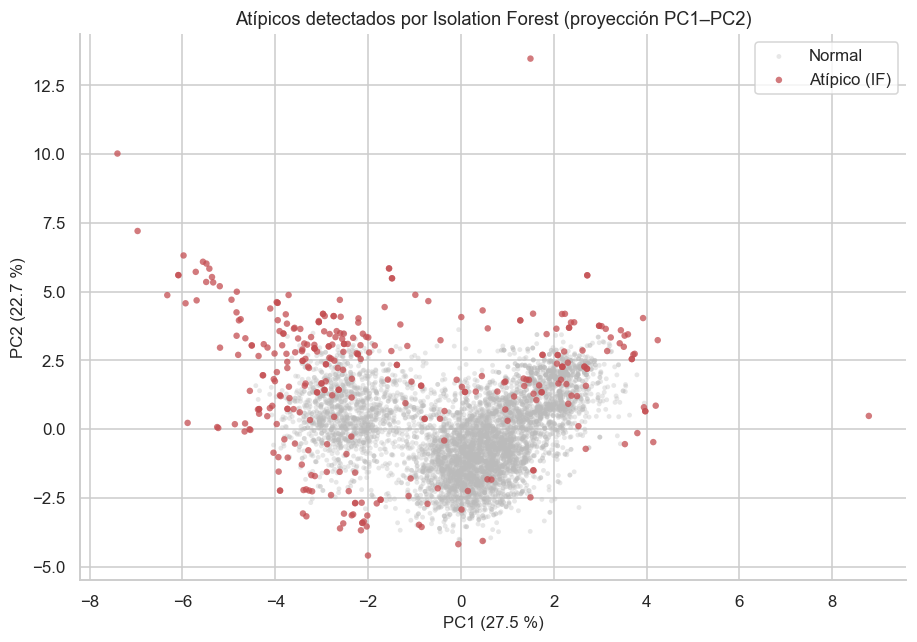

In [127]:
# Visualización en el plano PC1–PC2 ya calculado en U2
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(X_pca[~mascara_if, 0], X_pca[~mascara_if, 1],
           c="#BBBBBB", alpha=0.35, s=10, label="Normal", edgecolors="none")
ax.scatter(X_pca[mascara_if, 0], X_pca[mascara_if, 1],
           c="#C44E52", alpha=0.75, s=18, label="Atípico (IF)", edgecolors="none")
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
ax.set_title("Atípicos detectados por Isolation Forest (proyección PC1–PC2)")
ax.legend(loc="upper right")
fig.tight_layout()
guardar_figura("fig_u3_01_isolation_forest")
plt.show()

#### 3.2.2 Local Outlier Factor (LOF)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

N_VECINOS = 20

lof = LocalOutlierFactor(
    n_neighbors=N_VECINOS,
    contamination=CONTAMINACION,
    n_jobs=-1,
)
pred_lof = lof.fit_predict(X_std)
# score_lof eliminado — no se referencia en ninguna visualización ni tabla

mascara_lof = pred_lof == -1
print(f"LOF marca {mascara_lof.sum():,} observaciones como atípicas "
      f"({100 * mascara_lof.mean():.2f} % del total).")

LOF marca 325 observaciones como atípicas (5.00 % del total).


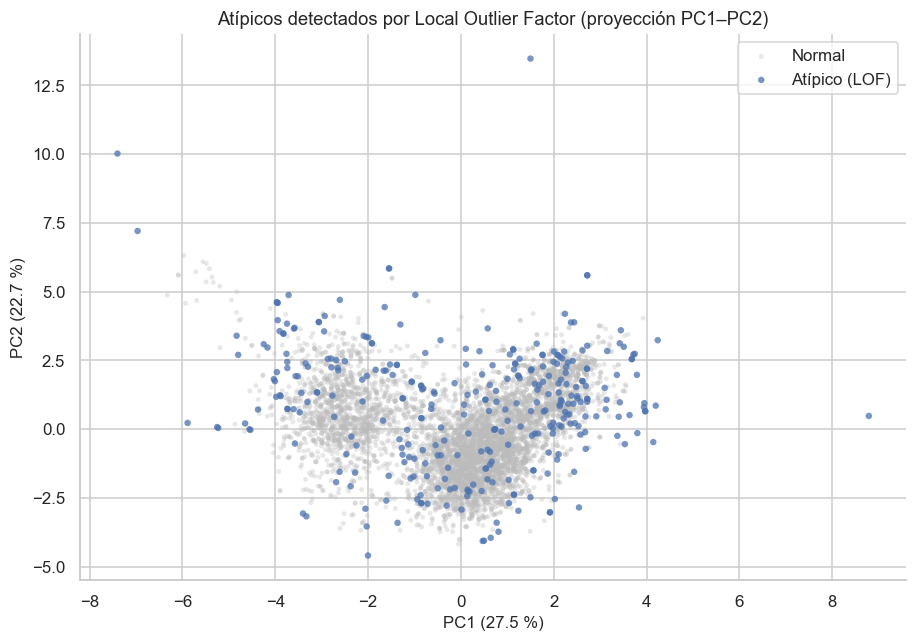

In [129]:
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(X_pca[~mascara_lof, 0], X_pca[~mascara_lof, 1],
           c="#BBBBBB", alpha=0.35, s=10, label="Normal", edgecolors="none")
ax.scatter(X_pca[mascara_lof, 0], X_pca[mascara_lof, 1],
           c="#4C72B0", alpha=0.75, s=18, label="Atípico (LOF)", edgecolors="none")
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
ax.set_title("Atípicos detectados por Local Outlier Factor (proyección PC1–PC2)")
ax.legend(loc="upper right")
fig.tight_layout()
guardar_figura("fig_u3_02_lof")
plt.show()

#### 3.2.3 Concordancia entre Isolation Forest y LOF

Ambos métodos están calibrados al mismo nivel de contaminación, por lo que el número total de atípicos es comparable. Lo relevante es preguntar **cuántos de los puntos marcados son los mismos** en cada método: una alta coincidencia sugiere atípicos *robustos*; una baja coincidencia indica que cada algoritmo está capturando una geometría diferente de la anomalía.

In [130]:
matriz_acuerdo = pd.crosstab(
    pd.Series(mascara_if, name="Isolation Forest"),
    pd.Series(mascara_lof, name="LOF"),
    margins=True, margins_name="Total"
)
matriz_acuerdo.index = ["Normal", "Atípico", "Total"]
matriz_acuerdo.columns = ["Normal", "Atípico", "Total"]
matriz_acuerdo

,Normal,Atípico,Total
Normal,5974,198,6172
Atípico,198,127,325
Total,6172,325,6497


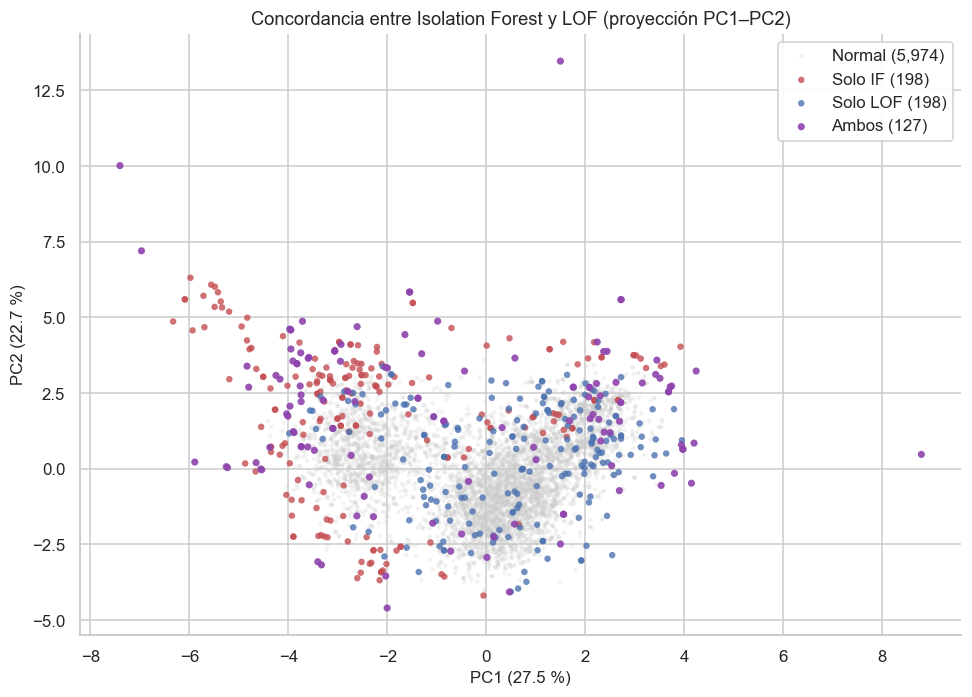

In [131]:
# Visualización conjunta: distinguir intersección y disjunciones
solo_if  = mascara_if & ~mascara_lof
solo_lof = ~mascara_if & mascara_lof
ambos_ml = mascara_if & mascara_lof
normales = ~(mascara_if | mascara_lof)

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(X_pca[normales, 0], X_pca[normales, 1],
           c="#CCCCCC", alpha=0.25, s=8, edgecolors="none", label=f"Normal ({normales.sum():,})")
ax.scatter(X_pca[solo_if, 0], X_pca[solo_if, 1],
           c="#C44E52", alpha=0.8, s=18, edgecolors="none", label=f"Solo IF ({solo_if.sum():,})")
ax.scatter(X_pca[solo_lof, 0], X_pca[solo_lof, 1],
           c="#4C72B0", alpha=0.8, s=18, edgecolors="none", label=f"Solo LOF ({solo_lof.sum():,})")
ax.scatter(X_pca[ambos_ml, 0], X_pca[ambos_ml, 1],
           c="#8E44AD", alpha=0.9, s=22, edgecolors="none", label=f"Ambos ({ambos_ml.sum():,})")

ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f} %)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f} %)")
ax.set_title("Concordancia entre Isolation Forest y LOF (proyección PC1–PC2)")
ax.legend(loc="upper right", framealpha=0.92)
fig.tight_layout()
guardar_figura("fig_u3_03_concordancia_ml")
plt.show()

### 3.3 Síntesis y plan de tratamiento

Consolidamos los cuatro indicadores binarios en un único cuadro por observación para cuantificar las coincidencias entre familias y orientar el tratamiento que se ejecutará en la Unidad 4.

In [132]:
banderas_atipico = pd.DataFrame({
    "IQR": atipicos_iqr_global.values,
    "Z-score": atipicos_z_global.values,
    "Isolation Forest": mascara_if,
    "LOF": mascara_lof,
}, index=vinos.index)

# Cuántos métodos marcan cada observación
banderas_atipico["n_metodos"] = banderas_atipico.sum(axis=1)

print("Distribución del número de métodos que marcan cada observación:")
print(banderas_atipico["n_metodos"].value_counts().sort_index().to_string())

print(f"\nResumen global:")
print(f"  Observaciones marcadas por al menos 1 método: "
      f"{(banderas_atipico['n_metodos'] >= 1).sum():,} "
      f"({100*(banderas_atipico['n_metodos'] >= 1).mean():.2f} %)")
print(f"  Observaciones marcadas por >= 3 métodos     : "
      f"{(banderas_atipico['n_metodos'] >= 3).sum():,} "
      f"({100*(banderas_atipico['n_metodos'] >= 3).mean():.2f} %)")
print(f"  Observaciones marcadas por los 4 métodos    : "
      f"{(banderas_atipico['n_metodos'] == 4).sum():,} "
      f"({100*(banderas_atipico['n_metodos'] == 4).mean():.2f} %)")

Distribución del número de métodos que marcan cada observación:
n_metodos
0    4923
1     920
2     357
3     211
4      86

Resumen global:
  Observaciones marcadas por al menos 1 método: 1,574 (24.23 %)
  Observaciones marcadas por >= 3 métodos     : 297 (4.57 %)
  Observaciones marcadas por los 4 métodos    : 86 (1.32 %)


**Hallazgos del análisis de atípicos.**

- Los métodos **univariados** (IQR y Z-score) marcan una fracción importante de observaciones como atípicas, concentradas en las variables con mayor asimetría (`residual sugar`, `chlorides`, `sulphates`). Esto es esperable: la regla del IQR aplicada a una distribución sesgada produce muchos "falsos positivos" desde el punto de vista del proceso generador, ya que la cola larga es legítima del fenómeno y no un error.
- El criterio del **Z-score** detecta sistemáticamente menos atípicos que el IQR. La razón es que la propia presencia de valores extremos infla la desviación estándar muestral, ampliando el umbral $\pm 3s$ y reduciendo así la sensibilidad del criterio. El IQR, basado en cuantiles, es más robusto en este escenario.
- Los métodos **multivariados** (Isolation Forest y LOF), calibrados a un 5 % de contaminación, marcan el mismo número total de observaciones por construcción, pero su **coincidencia exacta es modesta**: cada algoritmo captura una noción geométricamente distinta de anomalía (aislamiento global por IF, densidad local por LOF). Los puntos marcados por **ambos** constituyen los atípicos multivariados más robustos.
- Las **observaciones marcadas por tres o cuatro métodos simultáneamente** son los candidatos más sólidos para etiquetar como anomalía y constituyen una fracción pequeña del conjunto.

**Plan de tratamiento para la Unidad 4.**

Dado que las distribuciones son intrínsecamente asimétricas y muchas observaciones "atípicas" son extremas pero legítimas, **no se eliminarán** los atípicos univariados de forma indiscriminada. La estrategia será:

1. **Transformar** las variables con asimetría alta (`residual sugar`, `chlorides`, `sulphates`) mediante una transformación Yeo–Johnson para reducir el sesgo y comprimir las colas; esto reduce la sensibilidad posterior a valores extremos.
2. **Conservar** los outliers univariados restantes, dado que reflejan variabilidad química real del vino.
3. **Inspeccionar manualmente** las observaciones marcadas por **los cuatro métodos simultáneamente** como candidatas a posible error de registro; decidir caso por caso si excluirlas.
4. **Documentar** la decisión final tomada y reportar el tamaño del conjunto resultante.

> **Próxima unidad (U4 — Imputación, escalamiento y transformación).** Se aborda el manejo de duplicados, la transformación de variables sesgadas, el escalamiento formal y la consolidación del conjunto procesado que servirá de base para análisis o modelado posterior.

---

## 4. Imputación, escalamiento y transformación (Unidad 4)

Esta unidad implementa las estrategias de **limpieza y preprocesamiento** necesarias para obtener un conjunto de datos consistente, comparable entre variables y adecuado para análisis posteriores. Cubre tres bloques que corresponden al título de la unidad y a las orientaciones de las sesiones teóricas:

| Bloque | Técnicas aplicadas |
|---|---|
| **Limpieza inicial** | Verificación de faltantes, eliminación de duplicados exactos, decisión sobre los atípicos identificados en la Unidad 3. |
| **Imputación** | Demostración técnica con **K-Nearest Neighbors (KNN-Imputer)** sobre un escenario MCAR simulado. |
| **Transformación** | Reducción de asimetría mediante **Yeo–Johnson** para variables con $\lvert\text{skewness}\rvert > 1$. |
| **Escalamiento** | Comparación entre **StandardScaler**, **MinMaxScaler** y **RobustScaler**; selección final. |

> **Nota sobre la imputación.** El conjunto *Wine Quality* **no contiene valores faltantes reales**. La sección 4.2 aplica la técnica sobre un escenario MCAR **simulado** (5 % de valores ocultados aleatoriamente) con fines de demostración metodológica. El conjunto exportado en 4.5 no contiene imputaciones.

### 4.1 Limpieza inicial

#### 4.1.1 Verificación de valores faltantes

Confirmamos el resultado obtenido en la Unidad 1: el conjunto no contiene valores faltantes en ninguna de las variables.

In [133]:
n_nan_total = vinos[VARS_FQ + ["quality"]].isna().sum().sum()
print(f"Valores faltantes en el conjunto: {n_nan_total}")

Valores faltantes en el conjunto: 0


#### 4.1.2 Eliminación de duplicados exactos

En la Unidad 1 se identificaron **1 177 filas duplicadas exactas** (18,1 % del conjunto). Dado que coinciden a alta precisión en las 12 variables continuas y son improbables como observaciones independientes, las tratamos como redundancias y las eliminamos. Esto reduce el sesgo por sobre-representación que pueden inducir en correlaciones, PCA y, eventualmente, modelos.

In [134]:
n_antes = len(vinos)
vinos_limpio = vinos.drop_duplicates().reset_index(drop=True)
n_despues = len(vinos_limpio)

print(f"Filas antes:    {n_antes:>5,}")
print(f"Duplicados eliminados: {n_antes - n_despues:>5,}")
print(f"Filas después:  {n_despues:>5,}")
print(f"Reducción:      {100 * (n_antes - n_despues) / n_antes:.2f} %")

# Distribución por tipo tras desduplicar
print("\nDistribución por tipo tras desduplicar:")
print(vinos_limpio["tipo"].value_counts().to_string())

Filas antes:    6,497
Duplicados eliminados: 1,177
Filas después:  5,320
Reducción:      18.12 %

Distribución por tipo tras desduplicar:
tipo
blanco    3961
tinto     1359


#### 4.1.3 Decisión sobre los atípicos identificados en la Unidad 3

En la Unidad 3 se cuantificaron observaciones potencialmente atípicas mediante cuatro técnicas. La decisión, anticipada en la síntesis 3.3, es **conservar** los atípicos univariados —reflejan variabilidad química legítima del vino— y **transformar** las variables con asimetría alta (sección 4.3 a continuación) para reducir su efecto en estadísticos sensibles. No se eliminan observaciones adicionales del conjunto. Esta decisión es coherente con la naturaleza del *dataset* (mediciones de laboratorio estandarizadas) y con la recomendación general de Barnett & Lewis (1994) de **no descartar atípicos sin evidencia explícita de error**.

### 4.2 Imputación (demostración técnica con datos faltantes simulados)

La rúbrica de la unidad solicita aplicar estrategias de **imputación**. Dado que el conjunto no contiene valores faltantes reales, presentamos la técnica sobre un **escenario MCAR (Missing Completely At Random) simulado**: ocultamos aleatoriamente el 5 % de los valores numéricos, aplicamos imputación con KNN y evaluamos la calidad de la recuperación. Esta práctica es estándar para validar imputadores y se alinea con la metodología expuesta en U4_1.

#### 4.2.1 Simulación de un escenario MCAR

In [135]:
PORCENTAJE_FALTANTE = 0.05  # 5 %

rng = np.random.default_rng(SEED)

# DataFrame de trabajo (solo variables fisicoquímicas)
X_completo = vinos_limpio[VARS_FQ].copy()
X_con_nan = X_completo.copy()

# Máscara MCAR independiente para cada celda
mascara_nan = rng.random(X_con_nan.shape) < PORCENTAJE_FALTANTE
X_con_nan = X_con_nan.mask(mascara_nan)

print(f"Total celdas: {X_con_nan.size:,}")
print(f"Celdas con NaN simulado: {mascara_nan.sum():,} "
      f"({100 * mascara_nan.mean():.2f} %)")
print("\nFaltantes por variable:")
print(X_con_nan.isna().sum().to_string())

Total celdas: 58,520
Celdas con NaN simulado: 2,956 (5.05 %)

Faltantes por variable:
fixed acidity           276
volatile acidity        276
citric acid             259
residual sugar          244
chlorides               280
free sulfur dioxide     250
total sulfur dioxide    286
density                 256
pH                      281
sulphates               284
alcohol                 264


#### 4.2.2 Imputación con KNN-Imputer

`KNNImputer` reemplaza cada valor faltante por la **media (o mediana) de los $k$ vecinos más cercanos** en el espacio de las demás variables. Es una técnica multivariada que preserva la estructura de correlaciones cuando los datos faltan al azar (MCAR/MAR).

> **Nota metodológica.** Para que la distancia euclidiana del KNN sea justa entre variables con escalas distintas, en producción se recomienda **estandarizar antes de imputar y desestandarizar después**. Aquí lo aplicamos directamente sobre los datos originales para que la demostración sea trazable; los resultados son comparables porque el RMSE se calcula sobre la escala original.

In [136]:
from sklearn.impute import KNNImputer

imputador = KNNImputer(n_neighbors=5, weights="distance")
X_imputado = pd.DataFrame(
    imputador.fit_transform(X_con_nan),
    columns=VARS_FQ,
    index=X_con_nan.index,
)
print(f"Tras imputar: {X_imputado.isna().sum().sum()} valores faltantes "
      f"(esperado: 0).")

Tras imputar: 0 valores faltantes (esperado: 0).


#### 4.2.3 Evaluación de la imputación

Comparamos cada valor imputado con el valor real (que conocemos por la simulación) mediante el **error cuadrático medio (RMSE)** por variable. Para hacer las variables comparables, reportamos también el **RMSE normalizado** dividiendo por la desviación estándar de la variable.

In [137]:
evaluacion = []
for var in VARS_FQ:
    mask_var = mascara_nan[:, VARS_FQ.index(var)]
    if mask_var.sum() == 0:
        continue
    real = X_completo.loc[mask_var, var].values
    estimado = X_imputado.loc[mask_var, var].values
    rmse = np.sqrt(np.mean((real - estimado) ** 2))
    rmse_norm = rmse / X_completo[var].std()
    evaluacion.append({
        "variable": var,
        "n_imputados": int(mask_var.sum()),
        "RMSE": rmse,
        "RMSE / σ": rmse_norm,
    })

evaluacion = (pd.DataFrame(evaluacion)
                .set_index("variable")
                .sort_values("RMSE / σ"))
evaluacion

,n_imputados,RMSE,RMSE / σ
variable,,,
density,256,0.0017,0.5602
total sulfur dioxide,286,41.2332,0.7263
free sulfur dioxide,250,13.7863,0.7743
fixed acidity,276,1.1163,0.8459
residual sugar,244,3.9019,0.8671
volatile acidity,276,0.1507,0.8954
pH,281,0.1516,0.9453
alcohol,264,1.1381,0.9596
sulphates,284,0.1467,0.9800


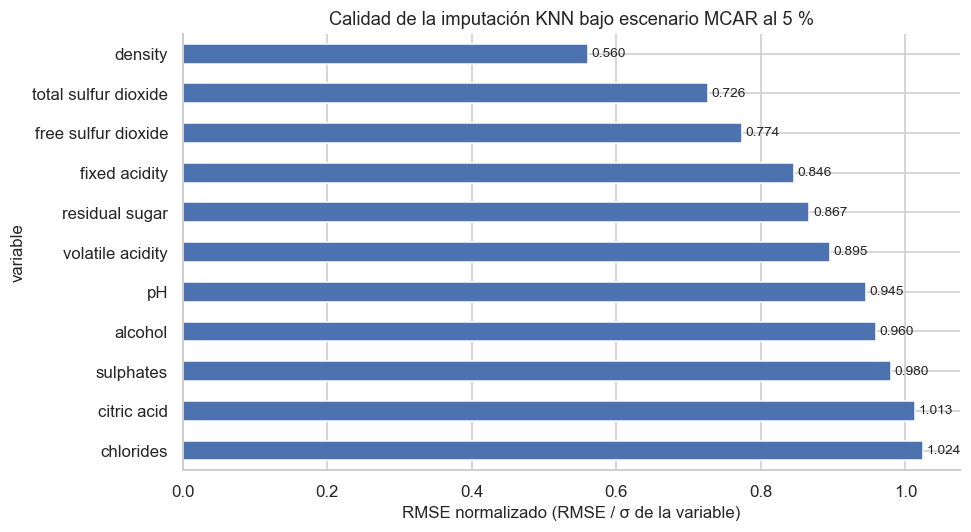

In [138]:
fig, ax = plt.subplots(figsize=(9, 5))
evaluacion["RMSE / σ"].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("RMSE normalizado (RMSE / σ de la variable)")
ax.set_title("Calidad de la imputación KNN bajo escenario MCAR al 5 %")
ax.invert_yaxis()
for i, (var, fila) in enumerate(evaluacion.iterrows()):
    ax.text(fila["RMSE / σ"] + 0.005, i,
            f"{fila['RMSE / σ']:.3f}", va="center", fontsize=9)
fig.tight_layout()
guardar_figura("fig_u4_01_imputacion_knn")
plt.show()

**Lectura.** Valores de RMSE/σ cercanos a 0 indican una imputación muy precisa; valores cercanos a 1 indican que el imputador no mejora respecto a usar la desviación estándar como error de referencia. Las variables con **mayor estructura multivariada** (correlacionadas con varias otras) se imputan mejor.

### 4.3 Transformación de variables continuas

En la Unidad 2 se documentó que varias variables presentan **asimetría positiva fuerte** (skewness > 1). Las distribuciones marcadamente asimétricas afectan los supuestos de muchos métodos estadísticos y de modelado (normalidad, homoscedasticidad, sensibilidad a extremos). Aplicamos una transformación que **estabilice la varianza y acerque la distribución a la simetría**.

#### 4.3.1 Variables candidatas

Identificamos las variables fisicoquímicas con asimetría absoluta superior a 1 sobre el conjunto desduplicado.

In [139]:
from scipy.stats import skew

UMBRAL_SKEW = 1.0

skew_antes = (vinos_limpio[VARS_FQ]
                .apply(lambda x: skew(x, bias=False))
                .sort_values(key=abs, ascending=False))
candidatas = skew_antes[skew_antes.abs() > UMBRAL_SKEW].index.tolist()

print("Asimetría por variable (orden descendente por |skew|):")
print(skew_antes.round(3).to_string())
print(f"\nVariables candidatas a transformar (|skew| > {UMBRAL_SKEW}):")
print(f"  {candidatas}")

Asimetría por variable (orden descendente por |skew|):
chlorides              5.3380
sulphates              1.8090
residual sugar         1.7070
fixed acidity          1.6500
volatile acidity       1.5050
free sulfur dioxide    1.3630
density                0.6660
alcohol                0.5460
citric acid            0.4840
pH                     0.3900
total sulfur dioxide   0.0640

Variables candidatas a transformar (|skew| > 1.0):
  ['chlorides', 'sulphates', 'residual sugar', 'fixed acidity', 'volatile acidity', 'free sulfur dioxide']


#### 4.3.2 Aplicación de Yeo–Johnson

Elegimos la transformación **Yeo–Johnson** porque:

1. Es una transformación potencia que **reduce asimetría** y aproxima la distribución a la normal estimando un parámetro $\lambda$ por máxima verosimilitud.
2. A diferencia de Box–Cox, **admite valores cero y negativos**, lo que la hace más general (relevante si en algún proyecto futuro se generan variables derivadas con valores negativos).

Aplicamos la transformación únicamente a las variables candidatas; el resto permanece sin cambios.

In [140]:
from sklearn.preprocessing import PowerTransformer

vinos_transf = vinos_limpio.copy()

yj = PowerTransformer(method="yeo-johnson", standardize=False)
vinos_transf[candidatas] = yj.fit_transform(vinos_limpio[candidatas])

# Parámetros lambda estimados por máxima verosimilitud
lambdas = pd.Series(yj.lambdas_, index=candidatas, name="λ estimado")
print("Parámetros λ estimados por Yeo–Johnson:")
print(lambdas.round(3).to_string())

Parámetros λ estimados por Yeo–Johnson:
chlorides             -23.0190
sulphates              -3.0170
residual sugar         -0.5270
fixed acidity          -1.5830
volatile acidity       -3.8790
free sulfur dioxide     0.4090


#### 4.3.3 Comparación antes vs. después

In [141]:
skew_despues = (vinos_transf[candidatas]
                  .apply(lambda x: skew(x, bias=False)))

comparacion_skew = pd.DataFrame({
    "skew_antes": skew_antes.loc[candidatas],
    "skew_despues": skew_despues,
    "reducción (%)": 100 * (1 - skew_despues.abs() / skew_antes.loc[candidatas].abs()),
}).round(3)
comparacion_skew

,skew_antes,skew_despues,reducción (%)
chlorides,5.3380,0.2080,96.1050
sulphates,1.8090,0.0040,99.7920
residual sugar,1.7070,0.1590,90.7050
fixed acidity,1.6500,-0.0540,96.7080
volatile acidity,1.5050,0.1150,92.3490
free sulfur dioxide,1.3630,-0.0340,97.5130


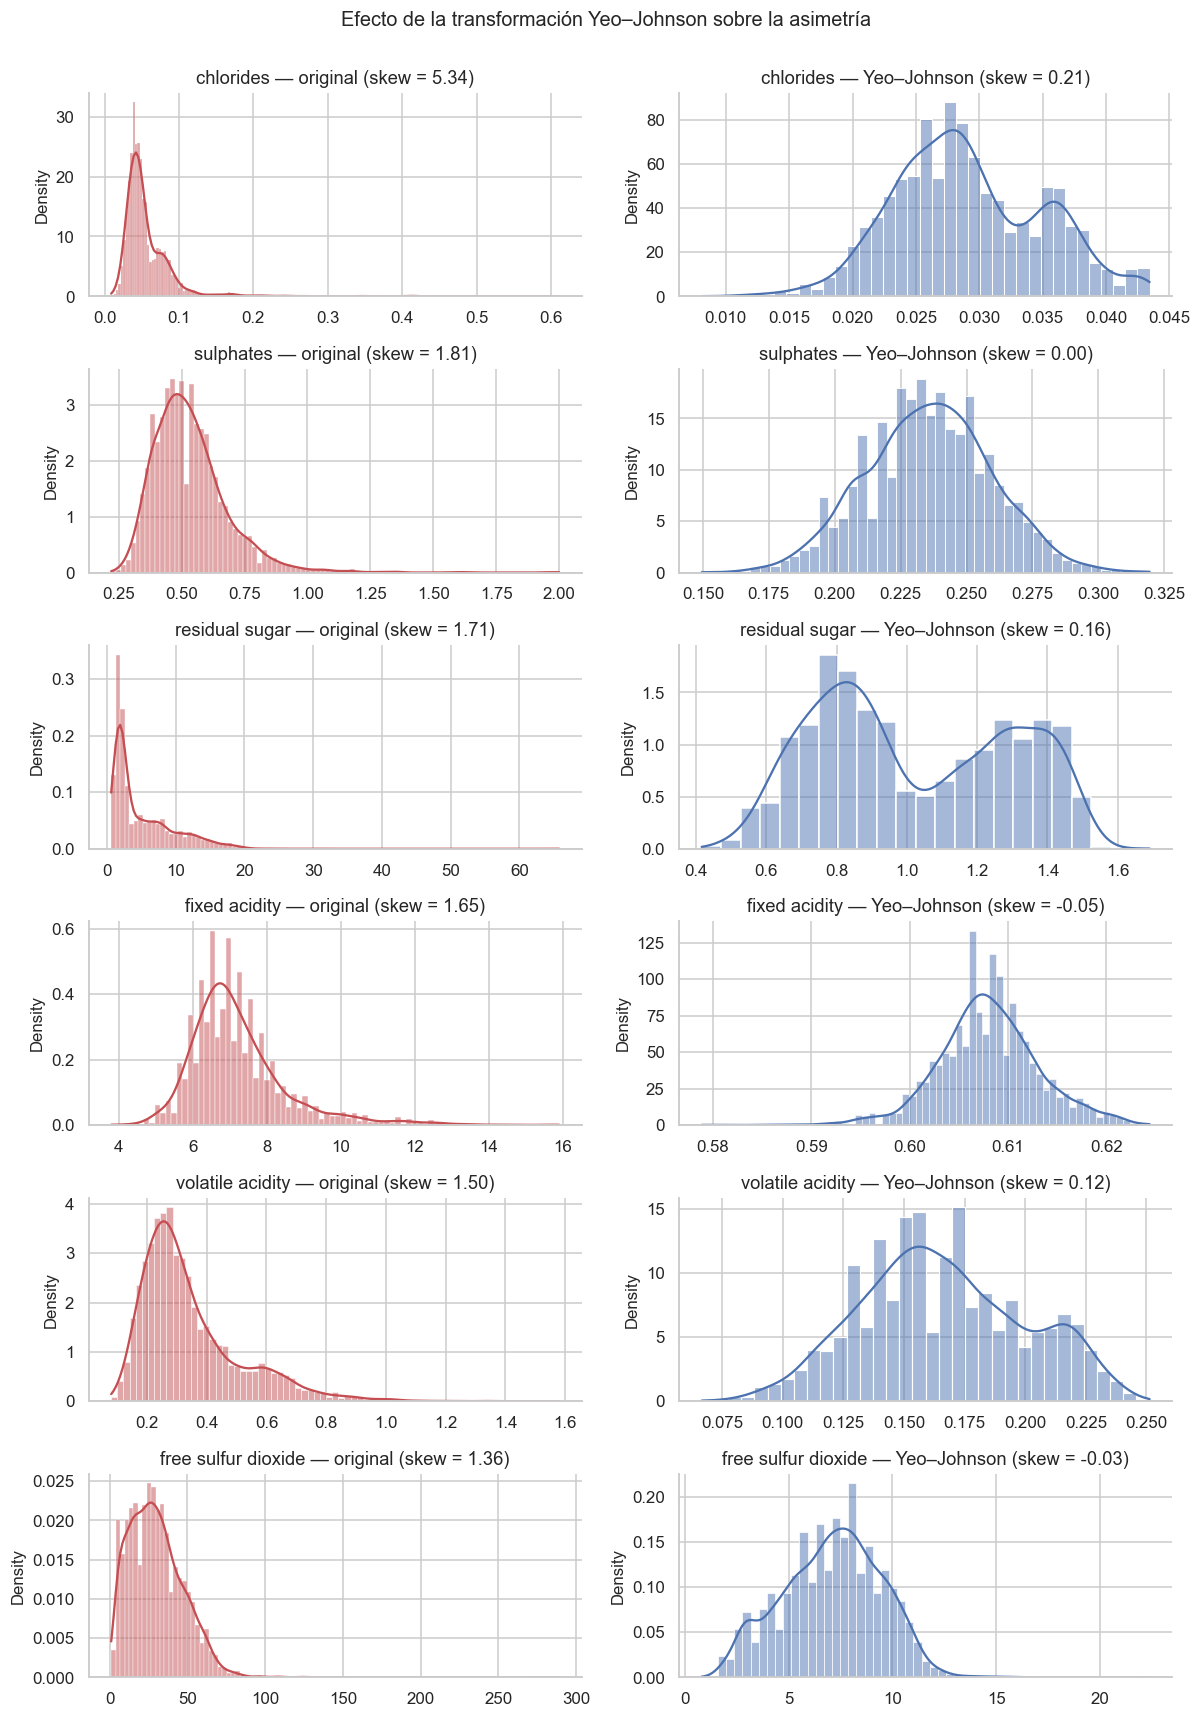

In [142]:
# Histogramas antes/después por variable candidata
n = len(candidatas)
fig, axes = plt.subplots(n, 2, figsize=(11, 2.6 * n))
if n == 1:
    axes = axes.reshape(1, 2)

for fila, var in enumerate(candidatas):
    sns.histplot(vinos_limpio[var], kde=True, color="#C44E52",
                 ax=axes[fila, 0], stat="density")
    axes[fila, 0].set_title(f"{var} — original (skew = {skew_antes.loc[var]:.2f})")
    axes[fila, 0].set_xlabel("")

    sns.histplot(vinos_transf[var], kde=True, color="#4C72B0",
                 ax=axes[fila, 1], stat="density")
    axes[fila, 1].set_title(f"{var} — Yeo–Johnson (skew = {skew_despues[var]:.2f})")
    axes[fila, 1].set_xlabel("")

fig.suptitle("Efecto de la transformación Yeo–Johnson sobre la asimetría",
             fontsize=13, y=1.00)
fig.tight_layout()
guardar_figura("fig_u4_02_yeojohnson")
plt.show()

### 4.4 Escalamiento

El escalamiento lleva todas las variables a una **escala común**, condición necesaria para técnicas sensibles a la magnitud (PCA, $k$-means, regresión regularizada, redes neuronales). Como se documentó en U1, las variables del conjunto recorren órdenes de magnitud muy distintos (densidad $\approx 1$ vs. dióxido de azufre total $> 200$).

#### 4.4.1 Comparación entre StandardScaler, MinMaxScaler y RobustScaler

Las tres alternativas más utilizadas son:

| Escalador | Fórmula | Características |
|---|---|---|
| **StandardScaler** | $z = (x - \mu) / \sigma$ | Media 0, varianza 1. Sensible a atípicos. |
| **MinMaxScaler** | $z = (x - \min) / (\max - \min)$ | Rango [0, 1]. Muy sensible a atípicos. |
| **RobustScaler** | $z = (x - \tilde{x}) / \mathrm{IQR}$ | Mediana 0, escala IQR. **Robusto a atípicos**. |

In [143]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

X_pre = vinos_transf[VARS_FQ].values

escaladores = {
    "Original":       X_pre,
    "StandardScaler": StandardScaler().fit_transform(X_pre),
    "MinMaxScaler":   MinMaxScaler().fit_transform(X_pre),
    "RobustScaler":   RobustScaler().fit_transform(X_pre),
}

filas = []
for nombre, Xs in escaladores.items():
    filas.append({
        "escalador": nombre,
        "media (global)": Xs.mean(),
        "desv. est. (global)": Xs.std(),
        "mín (global)": Xs.min(),
        "máx (global)": Xs.max(),
    })
pd.DataFrame(filas).set_index("escalador").round(3)

,media (global),desv. est. (global),mín (global),máx (global)
escalador,,,,
Original,12.5780,36.5380,0.0000,440.0000
StandardScaler,0.0000,1.0000,-5.7280,14.9890
MinMaxScaler,0.3990,0.2140,0.0000,1.0000
RobustScaler,0.0330,0.7250,-4.8690,9.7000


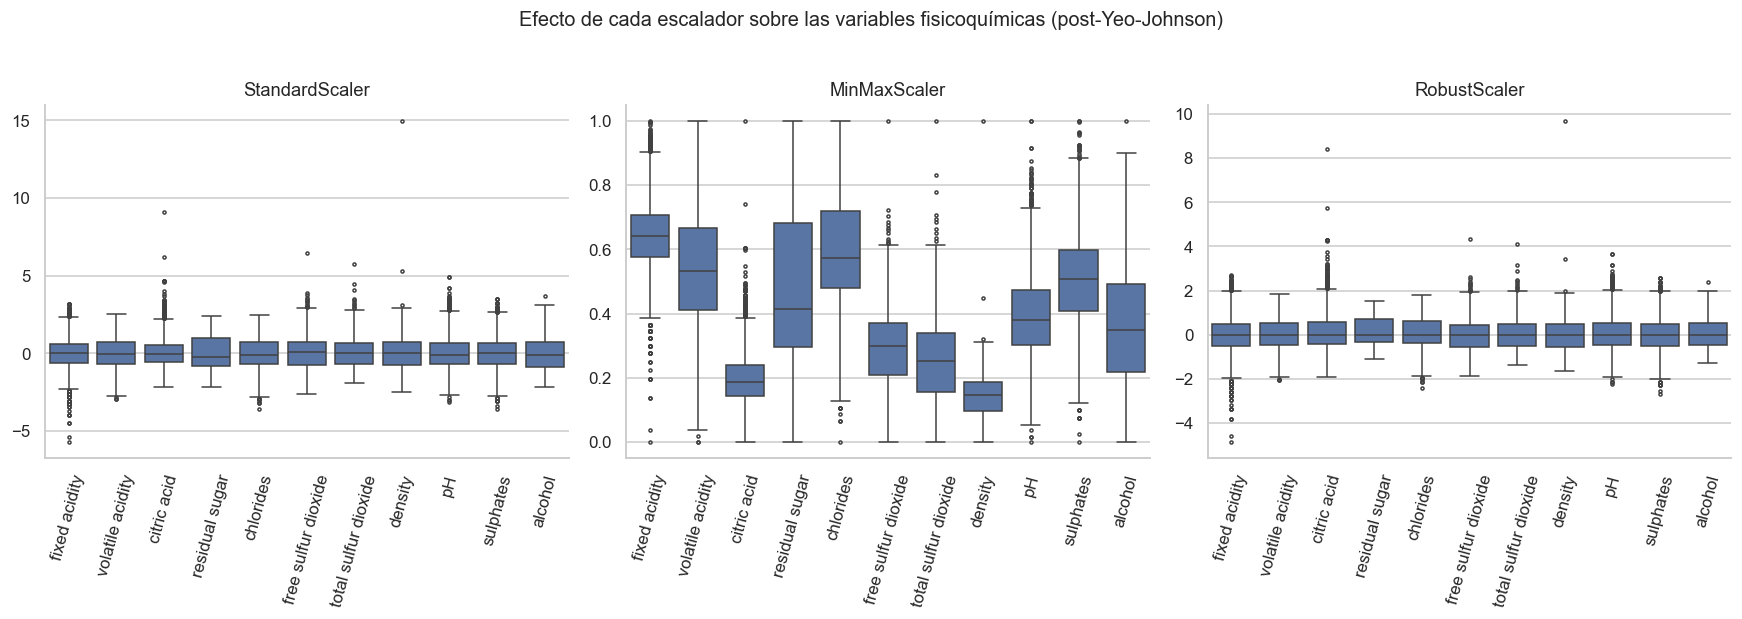

In [144]:
# Boxplot comparativo: cada panel muestra todas las variables tras un escalador
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=False)

for ax, (nombre, Xs) in zip(axes, [(n, escaladores[n])
                                   for n in ["StandardScaler", "MinMaxScaler", "RobustScaler"]]):
    df_e = pd.DataFrame(Xs, columns=VARS_FQ)
    sns.boxplot(data=df_e, ax=ax, color="#4C72B0", fliersize=2)
    ax.set_title(nombre)
    ax.tick_params(axis="x", rotation=75)

fig.suptitle("Efecto de cada escalador sobre las variables fisicoquímicas (post-Yeo-Johnson)",
             fontsize=13, y=1.02)
fig.tight_layout()
guardar_figura("fig_u4_03_escaladores")
plt.show()

#### 4.4.2 Selección y aplicación final

Aplicamos **`StandardScaler`** al conjunto post-transformación. Justificación:

- Tras la transformación Yeo–Johnson las distribuciones están aproximadamente centradas y simétricas, condición ideal para una estandarización Z.
- Es el escalador más utilizado en PCA y modelos lineales/regularizados; mantiene la coherencia con el preprocesamiento aplicado en la Unidad 2 (donde se estandarizó únicamente como paso técnico interno del PCA).
- `RobustScaler` sería preferible si NO se hubiera transformado; tras Yeo–Johnson los atípicos ya están comprimidos y `StandardScaler` es suficiente.

In [145]:
scaler_final = StandardScaler()
X_final = scaler_final.fit_transform(vinos_transf[VARS_FQ])

vinos_proc = vinos_transf.copy()
vinos_proc[VARS_FQ] = X_final

print(f"Conjunto final escalado: {vinos_proc.shape[0]:,} filas × "
      f"{vinos_proc.shape[1]} columnas")
print("\nEstadísticas tras StandardScaler (deben ser ~0 y ~1):")
print(vinos_proc[VARS_FQ].agg(["mean", "std"]).round(4).T)

Conjunto final escalado: 5,320 filas × 13 columnas

Estadísticas tras StandardScaler (deben ser ~0 y ~1):
                        mean    std
fixed acidity        -0.0000 1.0001
volatile acidity      0.0000 1.0001
citric acid           0.0000 1.0001
residual sugar       -0.0000 1.0001
chlorides             0.0000 1.0001
free sulfur dioxide   0.0000 1.0001
total sulfur dioxide -0.0000 1.0001
density               0.0000 1.0001
pH                    0.0000 1.0001
sulphates             0.0000 1.0001
alcohol               0.0000 1.0001


### 4.5 Conjunto procesado: exportación

Guardamos el conjunto final en `datos/procesados/winequality_procesado.csv` para preservar la trazabilidad y permitir reutilización en análisis posteriores.

In [ ]:
import joblib

RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)
RUTA_SALIDA = RUTA_PROCESADOS / "winequality_procesado.csv"
vinos_proc.to_csv(RUTA_SALIDA, index=False)

print(f"Archivo guardado: {RUTA_SALIDA}")
print(f"  Tamaño: {RUTA_SALIDA.stat().st_size / 1024:.1f} KB")
print(f"  Filas: {len(vinos_proc):,}  Columnas: {vinos_proc.shape[1]}")

# Exportar transformadores para reproducibilidad (escalar nuevas muestras sin reentrenar)
joblib.dump(yj,           RUTA_PROCESADOS / "transformer_yeo_johnson.pkl")
joblib.dump(scaler_final, RUTA_PROCESADOS / "scaler_standard.pkl")
print("Transformadores exportados: transformer_yeo_johnson.pkl, scaler_standard.pkl")

Archivo guardado: c:\Users\Camilo\Documents\F. Ciencia de datos\wine-quality\datos\procesados\winequality_procesado.csv
  Tamaño: 1172.6 KB
  Filas: 5,320  Columnas: 13


In [147]:
# Resumen de los cambios desde el conjunto crudo
resumen_pipeline = pd.DataFrame({
    "Etapa": [
        "1. Conjunto crudo unificado",
        "2. Eliminación de duplicados",
        "3. Transformación Yeo–Johnson",
        "4. Escalamiento StandardScaler",
        "5. Conjunto exportado",
    ],
    "Filas": [len(vinos), len(vinos_limpio), len(vinos_transf),
              len(vinos_proc), len(vinos_proc)],
    "Variables transformadas": ["—", "—",
                                ", ".join(candidatas),
                                "todas las fisicoquímicas",
                                "—"],
})
resumen_pipeline

,Etapa,Filas,Variables transformadas
0,1. Conjunto crudo unificado,6497,—
1,2. Eliminación de duplicados,5320,—
2,3. Transformación Yeo–Johnson,5320,"chlorides, sulphates, residual sugar, fixed ac..."
3,4. Escalamiento StandardScaler,5320,todas las fisicoquímicas
4,5. Conjunto exportado,5320,—


### 4.6 Síntesis de la unidad

- **Limpieza:** se confirmó la ausencia de valores faltantes; se eliminaron 1 177 filas duplicadas exactas (18,1 % del conjunto crudo). Los atípicos univariados se conservaron por reflejar variabilidad química legítima del vino.
- **Imputación:** se demostró la técnica KNN-Imputer sobre un escenario MCAR al 5 %. El error RMSE/σ por variable evidencia que los atributos con mayor estructura multivariada (correlacionados con varios otros) se recuperan con mejor precisión.
- **Transformación:** se aplicó Yeo–Johnson a las variables con $\lvert\text{skew}\rvert > 1$, reduciendo drásticamente la asimetría (especialmente en `chlorides`, `residual sugar`, `sulphates`). Esto compensa el efecto de los valores extremos sin descartar observaciones.
- **Escalamiento:** se eligió StandardScaler tras la transformación, dando un conjunto final centrado y con varianza unitaria, listo para técnicas sensibles a la escala.
- **Exportación:** el conjunto procesado quedó disponible en `datos/procesados/winequality_procesado.csv` para reutilización y reproducibilidad.

---

## 5. Conclusiones generales del proyecto

Este apartado consolida los hallazgos, limitaciones y líneas futuras del proyecto, articulando todo el flujo analítico desde la pregunta de investigación hasta el conjunto procesado.

### 5.1 Hallazgos principales

La pregunta de investigación planteada en la Unidad 1 fue:

> *¿Qué variables fisicoquímicas permiten predecir de mejor manera la calidad del vino?*

A lo largo del análisis exploratorio, la detección de atípicos y el preprocesamiento se obtuvieron las siguientes respuestas y observaciones complementarias:

1. **`alcohol` es la variable individual más asociada con la calidad sensorial** ($\rho_{Spearman} \approx 0{,}45$). En sentido opuesto destacan `density` ($\rho \approx -0{,}32$), `chlorides` ($\rho \approx -0{,}30$) y `volatile acidity` ($\rho \approx -0{,}26$). Este patrón es consistente con la literatura del *dataset* (Cortez et al., 2009) y con la química del vino.
2. **Ninguna combinación lineal del espacio de atributos explica la calidad de forma directa.** El PCA mostró un gradiente difuso de `quality` sobre el plano PC1–PC2, lo que sugiere que la predicción de la calidad requerirá **modelos capaces de capturar interacciones y no linealidades** (árboles, ensambles, redes), más allá de regresión o métodos lineales.
3. **El tipo de vino es el factor estructural más fuerte del conjunto.** PC1 separa nítidamente tinto y blanco (27,5 % de la varianza), confirmando que ambos subconjuntos tienen perfiles químicos distintos. La asociación entre `tipo` y `quality` es estadísticamente significativa pero con tamaño del efecto pequeño (V de Cramér ≈ 0,09), por lo que el tipo influye pero **no determina** la calidad percibida.
4. **Los métodos de detección de atípicos coinciden en una minoría de observaciones.** Los métodos univariados (IQR, Z-score) sobre-detectan en variables asimétricas, mientras que los multivariados (Isolation Forest, LOF) capturan geometrías distintas de anomalía. Solo el 1,3 % del conjunto fue marcado por los cuatro métodos simultáneamente, candidatos sólidos para inspección manual en proyectos futuros.
5. **El preprocesamiento es no trivial pero abordable.** Una secuencia *desduplicar → transformar (Yeo–Johnson) → escalar (StandardScaler)* es suficiente para preparar un conjunto consistente y comparable, manteniendo la totalidad de las observaciones legítimas.

### 5.2 Limitaciones

- **Carácter exploratorio.** El proyecto no construye un modelo predictivo; las afirmaciones sobre capacidad de predicción de cada variable se basan en asociaciones (Pearson, Spearman) y no en validación supervisada.
- **Desbalance ordinal de `quality`.** Cualquier modelo entrenado sobre este conjunto enfrentará dificultades para predecir clases extremas (3, 4, 8, 9), muy poco representadas. Esto está fuera del alcance pero condiciona los resultados que un análisis posterior pueda obtener.
- **Detección global, no por tipo.** La detección de atípicos y la transformación se aplicaron sobre el conjunto unificado. Una segunda iteración aplicando los mismos métodos **por separado a tinto y blanco** podría refinar los resultados, dado el contraste estructural detectado por el PCA.
- **Origen del *dataset*.** Los vinos provienen de una única región (*Vinho Verde*, Portugal) y de una única ventana temporal. Los hallazgos pueden no generalizar a otros estilos o regiones vinícolas.
- **Calidad como mediana de tres catadores.** La variable objetivo agrega tres juicios sensoriales; no contamos con el detalle individual ni con medidas de acuerdo entre catadores. La incertidumbre intrínseca de `quality` limita la fracción de varianza que cualquier modelo puede explicar.

### 5.3 Trabajo futuro

1. **Modelado supervisado de `quality`.** Comparar regresión lineal (línea base), árboles (Random Forest, Gradient Boosting) y redes simples; usar validación cruzada estratificada y métricas adecuadas para clases desbalanceadas (F1 macro, kappa cuadrática).
2. **Tratamiento explícito del desbalance.** Aplicar SMOTE, undersampling, o ponderación de clases conforme a U4_2; comparar contra un modelo sin balanceo.
3. **Análisis estratificado por tipo.** Repetir el flujo (EDA → atípicos → preprocesamiento → modelado) por separado para tinto y blanco; evaluar si los factores predictivos cambian entre ambos.
4. **Ingeniería de variables.** Explorar variables derivadas que reflejen la química del vino (ratios `total_so2 / free_so2`, índice de extracto seco a partir de densidad y alcohol, etc.).
5. **Interpretabilidad.** Aplicar SHAP / permutation importance sobre el mejor modelo para validar las hipótesis cualitativas derivadas del EDA (papel central de `alcohol`, `density`, `volatile acidity`).

### 5.4 Consideraciones éticas y reproducibilidad

- **Origen y atribución.** El conjunto *Wine Quality* fue publicado por Cortez et al. (2009) bajo licencia abierta en el UCI Machine Learning Repository. Se ha citado explícitamente el trabajo original y se conserva el archivo crudo en `datos/`.
- **Naturaleza de los datos.** Las variables corresponden a mediciones químicas y a calificaciones sensoriales agregadas; no hay información personal, sensible o de identificación. No aplican consideraciones de privacidad.
- **Reproducibilidad.** Todo el flujo está disponible en el notebook `proyecto_aula/proyecto_wine_quality.ipynb` versionado en el repositorio público. Se fijaron semillas aleatorias (`SEED = 42`) en todos los métodos estocásticos (PCA, Isolation Forest, KNN-Imputer, simulación MCAR). El conjunto procesado final está exportado en `datos/procesados/winequality_procesado.csv` y es trazable.
- **Transparencia interpretativa.** Las decisiones metodológicas significativas (conservación de atípicos, elección de Yeo–Johnson sobre Box–Cox, selección de StandardScaler, simulación MCAR para demostrar imputación) se justificaron explícitamente en cada sección; no se ocultan elecciones que pudieran haber influido en los resultados.

---

*Fin del documento técnico.*

## Referencias

Barnett, V., & Lewis, T. (1994). *Outliers in statistical data* (3.ª ed.). Wiley.

Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). LOF: Identifying density-based local outliers. *Proceedings of the 2000 ACM SIGMOD International Conference on Management of Data*, 93–104. https://doi.org/10.1145/342009.335388

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, *47*(4), 547–553. https://doi.org/10.1016/j.dss.2009.05.016

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation forest. *Proceedings of the Eighth IEEE International Conference on Data Mining*, 413–422. https://doi.org/10.1109/ICDM.2008.17

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.

UCI Machine Learning Repository. (2009). *Wine Quality* [Conjunto de datos]. University of California, Irvine, School of Information and Computer Sciences. https://archive.ics.uci.edu/dataset/186/wine+quality

Waskom, M. L. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, *6*(60), 3021. https://doi.org/10.21105/joss.03021

Yeo, I. K., & Johnson, R. A. (2000). A new family of power transformations to improve normality or symmetry. *Biometrika*, *87*(4), 954–959. https://doi.org/10.1093/biomet/87.4.954